# Dynamic small-account optimisation: computable intuition

This notebook turns the current checkout's `systems.provided.dynamic_small_system_optimise` calculation chain into an inspectable experiment. Its central question is not merely whether the system runs, but how market state becomes a signal, a continuous mathematical portfolio, a physical integer portfolio, and finally an economic trade/no-trade decision.

Safety boundary: this notebook uses only repository CSV simulation data. It does not import production data adapters, connect to IB/TWS, submit orders, write positions, access MongoDB, or modify production configuration/data. Generated caches stay under `project/notebooks/output/`.

The default `QUICK_MODE=True` preserves every core visualisation with a shorter date range and smaller parameter grids. Set it to `False` for the larger universe and sweeps.

In [1]:
from pathlib import Path
import logging
import os
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "systems").exists() and (candidate / "project").exists():
            return candidate
    raise RuntimeError("Could not find the pysystemtrade repository root")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
OUTPUT_DIR = REPO_ROOT / "project" / "notebooks" / "output"
CACHE_DIR = OUTPUT_DIR / "small_account_cache"
MPL_CONFIG_DIR = OUTPUT_DIR / "matplotlib"
for path in (OUTPUT_DIR, CACHE_DIR, MPL_CONFIG_DIR):
    path.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG_DIR)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from project.notebooks.research.small_account_diagnostics import (
    ExperimentSpec, Timer, available_instruments, build_system, cache_key,
    candidate_objective_table, capital_heatmap_frames, capital_sweep,
    collect_core_frames, compare_native_replay, covariance_and_correlation_frames,
    decision_snapshot, default_spec, diagnostics_long, enrich_position_frames,
    environment_manifest, find_decision_events, heatmap, method_metrics,
    objective_for_date, parameter_sweep, phase_transition_table,
    risk_contributions, run_optimisation, sanity_checks, style_axes,
    tracking_error_series, universe_diagnostic,
)
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysquant.optimisation.weights import portfolioWeights

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "legend.frameon": False})
logging.getLogger().setLevel(logging.CRITICAL)

Configuring sim logging


## Experiment configuration

The universe was chosen only after checking the packaged CSV data: it covers equity index, rates, FX, metals, energy and agriculture, and includes large/micro pairs. The capital grid is logarithmic enough to cross distinct granularity regimes. Units are explicit: capital and costs are USD; volatility and portfolio weights are fractions unless marked `%`; positions are contracts.

In [2]:
QUICK_MODE = True
START_DATE = "2021-01-01" if QUICK_MODE else "2016-01-01"
END_DATE = None
CAPITAL_BASE = 100_000.0
SELECTED_INSTRUMENTS = [
    "SP500", "SP500_micro", "NASDAQ_micro", "US10",
    "EUR_micro", "GOLD_micro", "CRUDE_W", "CORN",
]
if not QUICK_MODE:
    SELECTED_INSTRUMENTS += ["NASDAQ", "EUR", "GOLD"]
FOCUS_INSTRUMENTS = ["SP500_micro", "SP500", "GOLD_micro"]
CAPITAL_SWEEP = [25_000.0, 100_000.0, 400_000.0] if QUICK_MODE else [25_000.0, 50_000.0, 100_000.0, 200_000.0, 500_000.0, 1_000_000.0]
SHADOW_COST_VALUES = [0.0, 50.0, 100.0] if QUICK_MODE else [0.0, 25.0, 50.0, 100.0, 200.0]
TRACKING_ERROR_BUFFER_VALUES = [0.0, 0.0125, 0.025] if QUICK_MODE else [0.0, 0.00625, 0.0125, 0.025, 0.05]
COST_MULTIPLIER_VALUES = [0.5, 1.0, 2.0] if QUICK_MODE else [0.5, 1.0, 2.0, 4.0]
CORRELATION_SHRINKAGE_VALUES = [0.0, 0.5, 1.0] if QUICK_MODE else [0.0, 0.25, 0.5, 0.75, 1.0]
RANDOM_SEED = 20260916
np.random.seed(RANDOM_SEED)

raw_data = csvFuturesSimData()
SELECTED_INSTRUMENTS = available_instruments(raw_data, SELECTED_INSTRUMENTS)
FOCUS_INSTRUMENTS = available_instruments(raw_data, FOCUS_INSTRUMENTS)
assert SELECTED_INSTRUMENTS and FOCUS_INSTRUMENTS

spec = ExperimentSpec(
    quick_mode=QUICK_MODE, start_date=START_DATE, end_date=END_DATE,
    capital_base=CAPITAL_BASE, selected_instruments=tuple(SELECTED_INSTRUMENTS),
    focus_instruments=tuple(FOCUS_INSTRUMENTS), capital_sweep=tuple(CAPITAL_SWEEP),
    shadow_cost_values=tuple(SHADOW_COST_VALUES),
    tracking_error_buffer_values=tuple(TRACKING_ERROR_BUFFER_VALUES),
    cost_multiplier_values=tuple(COST_MULTIPLIER_VALUES),
    correlation_shrinkage_values=tuple(CORRELATION_SHRINKAGE_VALUES),
    random_seed=RANDOM_SEED,
)
display(pd.Series({
    "mode": "QUICK" if QUICK_MODE else "FULL", "start": START_DATE, "end": END_DATE or "latest CSV date",
    "capital_usd": CAPITAL_BASE, "instruments": ", ".join(SELECTED_INSTRUMENTS),
    "focus": ", ".join(FOCUS_INSTRUMENTS), "random_seed": RANDOM_SEED,
}, name="value").to_frame())

,value
mode,QUICK
start,2021-01-01
end,latest CSV date
capital_usd,100000.0
instruments,"SP500, SP500_micro, NASDAQ_micro, US10, EUR_mi..."
focus,"SP500_micro, SP500, GOLD_micro"
random_seed,20260916


## System map

```mermaid
flowchart TD
    P[CSV adjusted and multiple prices] --> V[RawData: daily prices and volatility]
    P --> R[Rules: raw EWMAC forecasts]
    R --> SC[ForecastScaleCap: scaled and capped forecasts]
    SC --> FC[ForecastCombine: combined forecast]
    V --> PS[PositionSizing: average and subsystem contracts]
    FC --> PS
    PS --> PF[Portfolios: instrument weight × IDM → continuous contracts]
    PF --> DO[optimisedPositions: continuous contracts → optimal weights]
    V --> CV[annual percentage vol + correlation → covariance]
    CV --> DO
    P --> G[contract value / capital]
    G --> DO
    C[previous integer positions + costs + constraints] --> DO
    DO --> OBJ[tracking-error std + shadow-cost trading penalty + constraint penalty]
    OBJ --> GR[greedy integer search from feasible zero/minimum]
    GR --> B[tracking-error buffer partial-trade adjustment]
    B --> I[integer contracts]
    I --> O[realised exposure, risk, turnover, cost and P&L]
```

Actual source trace: `systems/rawdata.py` → `systems/forecasting.py` → `systems/forecast_scale_cap.py` → `systems/forecast_combine.py` → `systems/positionsizing.py` → `systems/portfolio.py` → `systems/provided/dynamic_small_system_optimise/{optimised_positions_stage.py, optimisation.py, greedy_algo.py, buffering.py}` → `systems/risk.py` and `accounts_stage.py`.

Important implementation detail: covariance is built from annual percentage-volatility fractions and the date-appropriate instrument correlation estimate. The optimizer works in portfolio-weight space, but moves in whole-contract increments using `per_contract_value / capital`.

## Reproducibility manifest and resolved native configuration

In [3]:
display(environment_manifest(REPO_ROOT).to_frame())
timings = {}
with Timer(timings, "system_build_seconds"):
    system = build_system(spec)
logging.getLogger().setLevel(logging.CRITICAL)
display(pd.Series({
    "small_system": system.config.small_system,
    "notional_trading_capital": system.config.notional_trading_capital,
    "percentage_vol_target": system.config.percentage_vol_target,
    "base_currency": system.config.base_currency,
}, name="resolved value").to_frame())

,value
git_commit,11619a9cbe1b271912d3812b70e4be4e05fc83b3
git_branch,develop
python,3.12.3
python_executable,D:\dev\pysystemtrade\.venv-py312\Scripts\pytho...
pysystemtrade_path,D:\dev\pysystemtrade
data_source,csvFuturesSimData (repository CSV files; read-...
run_timestamp_utc,2026-09-16T16:01:12.073869+00:00


,resolved value
small_system,"{'shadow_cost': 50.0, 'cost_multiplier': 1.0, ..."
notional_trading_capital,100000.0
percentage_vol_target,25.0
base_currency,USD


## Diagnostic layer and universe selection

In [4]:
with Timer(timings, "continuous_and_diagnostics_seconds"):
    frames = collect_core_frames(system, spec)
universe = universe_diagnostic(system, frames)
display(universe.style.format({
    "price": "{:,.4f}", "multiplier": "{:,.2f}", "fx": "{:.4f}",
    "annual_vol": "{:.2%}", "one_contract_value": "${:,.0f}",
    "one_contract_risk": "${:,.0f}", "granularity_ratio": "{:.2f}", "cost": "${:,.2f}",
}))

,asset_class,data_start,data_end,price,multiplier,fx,annual_vol,one_contract_value,one_contract_risk,granularity_ratio,cost
instrument,,,,,,,,,,,
EUR_micro,FX,2021-01-04 00:00:00,2024-03-28 00:00:00,1.0821,"12,500.00",1.0000,5.82%,"$13,526",$787,0.03,$1.15
GOLD_micro,Metals,2021-01-04 00:00:00,2024-03-28 00:00:00,"2,255.0000",10.00,1.0000,11.61%,"$22,550","$2,619",0.10,$1.65
SP500_micro,Equity,2021-01-04 00:00:00,2024-03-28 00:00:00,"5,303.7500",5.00,1.0000,10.11%,"$26,519","$2,682",0.11,$1.27
CORN,Ags,2021-01-04 00:00:00,2024-03-28 00:00:00,477.7500,50.00,1.0000,20.16%,"$23,888","$4,816",0.19,$10.97
NASDAQ_micro,Equity,2021-01-04 00:00:00,2024-03-28 00:00:00,"18,465.2500",2.00,1.0000,13.86%,"$36,930","$5,118",0.20,$1.10
US10,Bond,2021-01-04 00:00:00,2024-03-28 00:00:00,110.7188,"1,000.00",1.0000,5.57%,"$110,719","$6,167",0.25,$9.67
CRUDE_W,OilGas,2021-01-04 00:00:00,2024-03-28 00:00:00,77.6800,"1,000.00",1.0000,18.24%,"$77,680","$14,169",0.57,$14.37
SP500,Equity,2021-01-04 00:00:00,2024-03-28 00:00:00,"5,304.2500",50.00,1.0000,10.10%,"$265,212","$26,784",1.07,$8.75


The table is the first implementation diagnostic. `granularity_ratio` is standalone annual risk from one contract divided by the portfolio's annual risk budget; values near or above 1 mean that a single contract can consume most or all of the target risk. Cost is the native deflated one-contract estimate on the latest date, before the optimizer's shadow-cost multiplier.

## Native dynamic optimisation and unified `diagnostics_long`

In [5]:
base_cache_id = cache_key(spec, "base_native_replay")
with Timer(timings, "dynamic_optimisation_seconds"):
    optimised = run_optimisation(system, frames, cache_dir=CACHE_DIR, cache_id=base_cache_id)
frames = enrich_position_frames(frames, optimised)
with Timer(timings, "diagnostics_long_seconds"):
    diagnostics = diagnostics_long(frames)
portfolio_tracking = tracking_error_series(system, frames, optimised)
print(f"diagnostics_long: {diagnostics.shape[0]:,} date×instrument rows, {diagnostics.shape[1]} variables")
display(diagnostics.tail(8).round(5))

diagnostics_long: 6,752 date×instrument rows, 34 variables


price  price_return  daily_price_vol_pct  annual_pct_vol_fraction  instrument_currency_daily_vol  \
date       instrument                                                                                                             
2024-03-28 CORN            477.75000      15.50000              1.26010                  0.20162                      301.00727   
           CRUDE_W          77.68000       0.66000              1.14005                  0.18241                      885.58944   
           EUR_micro         1.08210      -0.00360              0.36354                  0.05817                       49.17376   
           GOLD_micro     2255.00000      39.60000              0.72591                  0.11615                      163.69250   
           NASDAQ_micro  18465.25000     -40.75000              0.86612                  0.13858                      319.86220   
           SP500          5304.25000      -4.00000              0.63119                  0.10099                     1673.99265   
           SP500_micro    5303.75000      -4.25000              0.63218                  0.10115                      167.64742   
           US10            110.71875      -0.15625              0.34814                  0.05570                      385.45796   

                         base_currency_daily_vol  combined_forecast  average_position  subsystem_position  instrument_weight  ...  \
date       instrument                                                                                                         ...   
2024-03-28 CORN                        301.00727           -4.13973           5.19090            -2.14889              0.125  ...   
           CRUDE_W                     885.58944            9.08810           1.76436             1.60347              0.125  ...   
           EUR_micro                    49.17376           -2.56311          31.77508            -8.14429              0.125  ...   
           GOLD_micro                  163.69250           14.97707           9.54534            14.29612              0.125  ...   
           NASDAQ_micro                319.86220           12.59098           4.88492             6.15059              0.125  ...   
           SP500                      1673.99265           18.49026           0.93340             1.72588              0.125  ...   
           SP500_micro                 167.64742           18.54430           9.32016            17.28358              0.125  ...   
           US10                        385.45796           -2.74367           4.05362            -1.11218              0.125  ...   

                         raw_forecast__ewmac8_32  scaled_forecast__ewmac8_32  capped_forecast__ewmac8_32  optimised_position  \
date       instrument                                                                                                          
2024-03-28 CORN                          0.22178                     1.17543                     1.17543                -1.0   
           CRUDE_W                       1.93890                    10.27615                    10.27615                 0.0   
           EUR_micro                    -0.66942                    -3.54793                    -3.54793                -2.0   
           GOLD_micro                    3.11312                    16.49956                    16.49956                 3.0   
           NASDAQ_micro                  1.20146                     6.36772                     6.36772                 1.0   
           SP500                         2.56956                    13.61865                    13.61865                 1.0   
           SP500_micro                   2.58810                    13.71691                    13.71691                 2.0   
           US10                         -0.44838                    -2.37639                    -2.37639                 0.0   

                         previous_integer_position  position_change  nearest_integer_position  toward_zero_p

`diagnostics_long` is the common source for later views. It contains market, signal, risk scaling, continuous target, contract granularity, native cost, prior/actual integer position and tracking-error variables; charts do not recompute independent versions of the same state.

## World 0 — Price

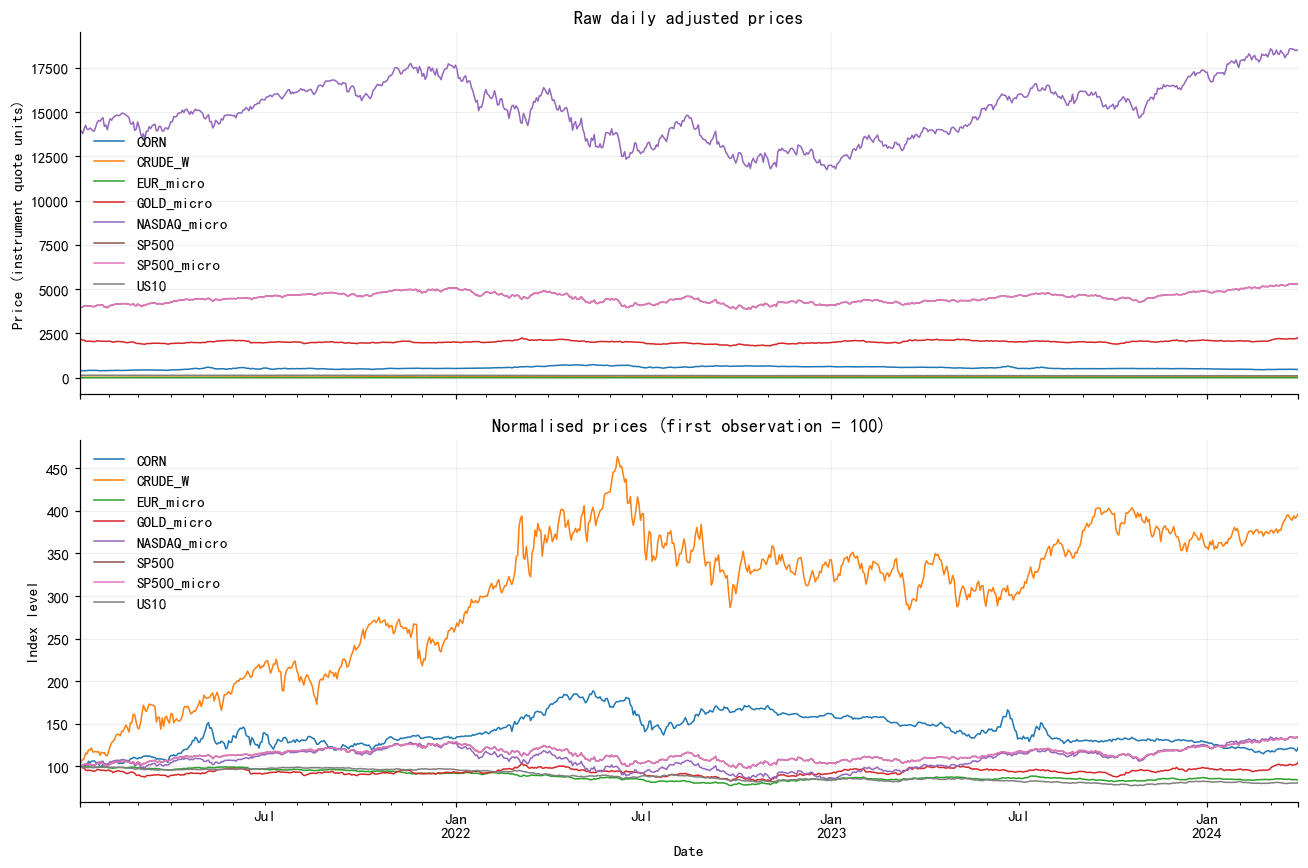

In [6]:
price = frames["price"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
price.plot(ax=axes[0], lw=1.0)
axes[0].set(title="Raw daily adjusted prices", ylabel="Price (instrument quote units)", xlabel="")
normalised = price.divide(price.apply(lambda s: s.dropna().iloc[0])).mul(100)
normalised.plot(ax=axes[1], lw=1.0)
axes[1].set(title="Normalised prices (first observation = 100)", ylabel="Index level", xlabel="Date")
style_axes(axes); fig.tight_layout()

Raw prices establish the market state; normalisation makes unlike quote units comparable. Observe that similar economic exposures, such as S&P full and micro, share direction even though their contract multipliers differ by 10×.

## World 1 — Price movement → forecast

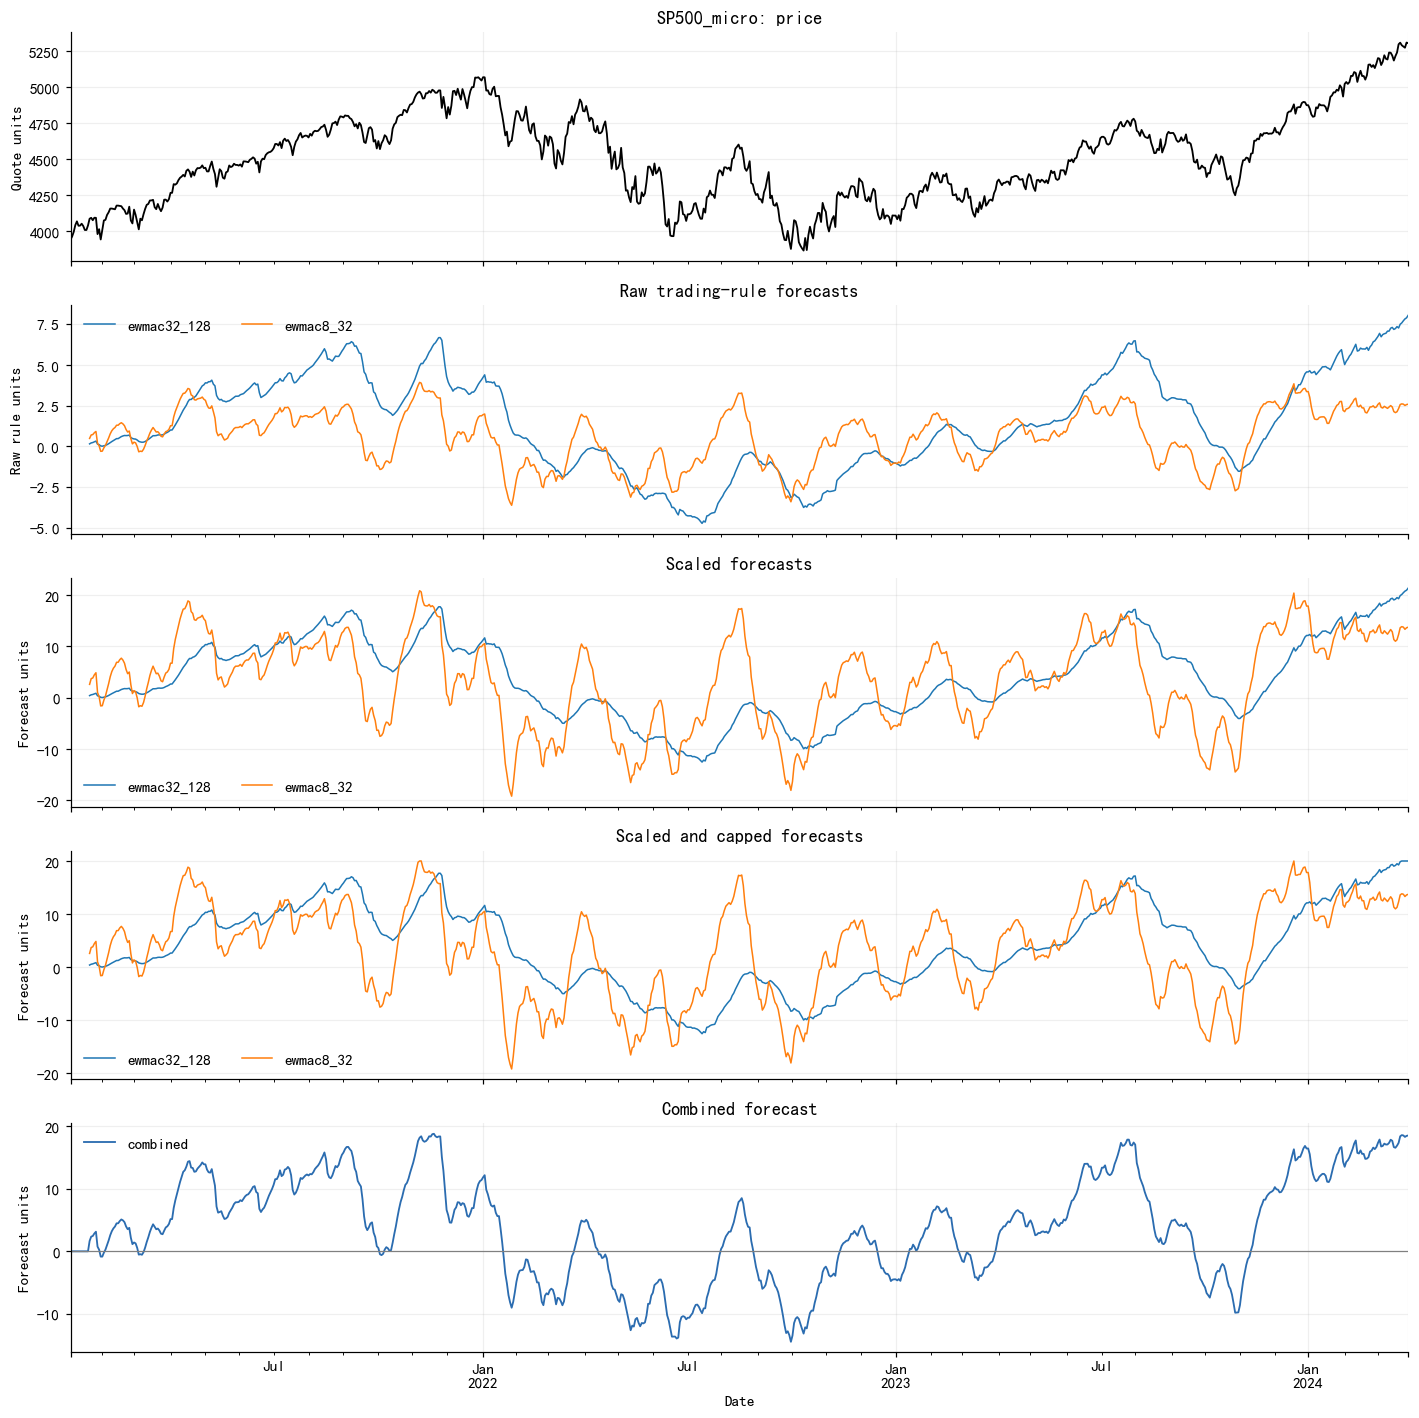

In [7]:
FOCUS = FOCUS_INSTRUMENTS[0]
rule_names = [name.split("__", 1)[1] for name in frames if name.startswith("raw_forecast__")]
fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)
frames["price"][FOCUS].plot(ax=axes[0], color="black", lw=1.2)
axes[0].set(title=f"{FOCUS}: price", ylabel="Quote units")
for rule in rule_names:
    frames[f"raw_forecast__{rule}"][FOCUS].plot(ax=axes[1], label=rule, lw=1)
    frames[f"scaled_forecast__{rule}"][FOCUS].plot(ax=axes[2], label=rule, lw=1)
    frames[f"capped_forecast__{rule}"][FOCUS].plot(ax=axes[3], label=rule, lw=1)
axes[1].set(title="Raw trading-rule forecasts", ylabel="Raw rule units")
axes[2].set(title="Scaled forecasts", ylabel="Forecast units")
axes[3].set(title="Scaled and capped forecasts", ylabel="Forecast units")
frames["combined_forecast"][FOCUS].plot(ax=axes[4], color="#2b6cb0", label="combined", lw=1.2)
axes[4].axhline(0, color="grey", lw=.8)
axes[4].set(title="Combined forecast", ylabel="Forecast units", xlabel="Date")
for ax in axes[1:]: ax.legend(ncol=3)
style_axes(axes); fig.tight_layout()

The panels preserve the causal ordering: price feeds raw EWMAC rules; configured scalars put rules on comparable forecast units; capping and fixed combination produce the signal used for sizing. A forecast is direction/strength, not contracts or portfolio weight.

## Volatility, contract risk and account granularity

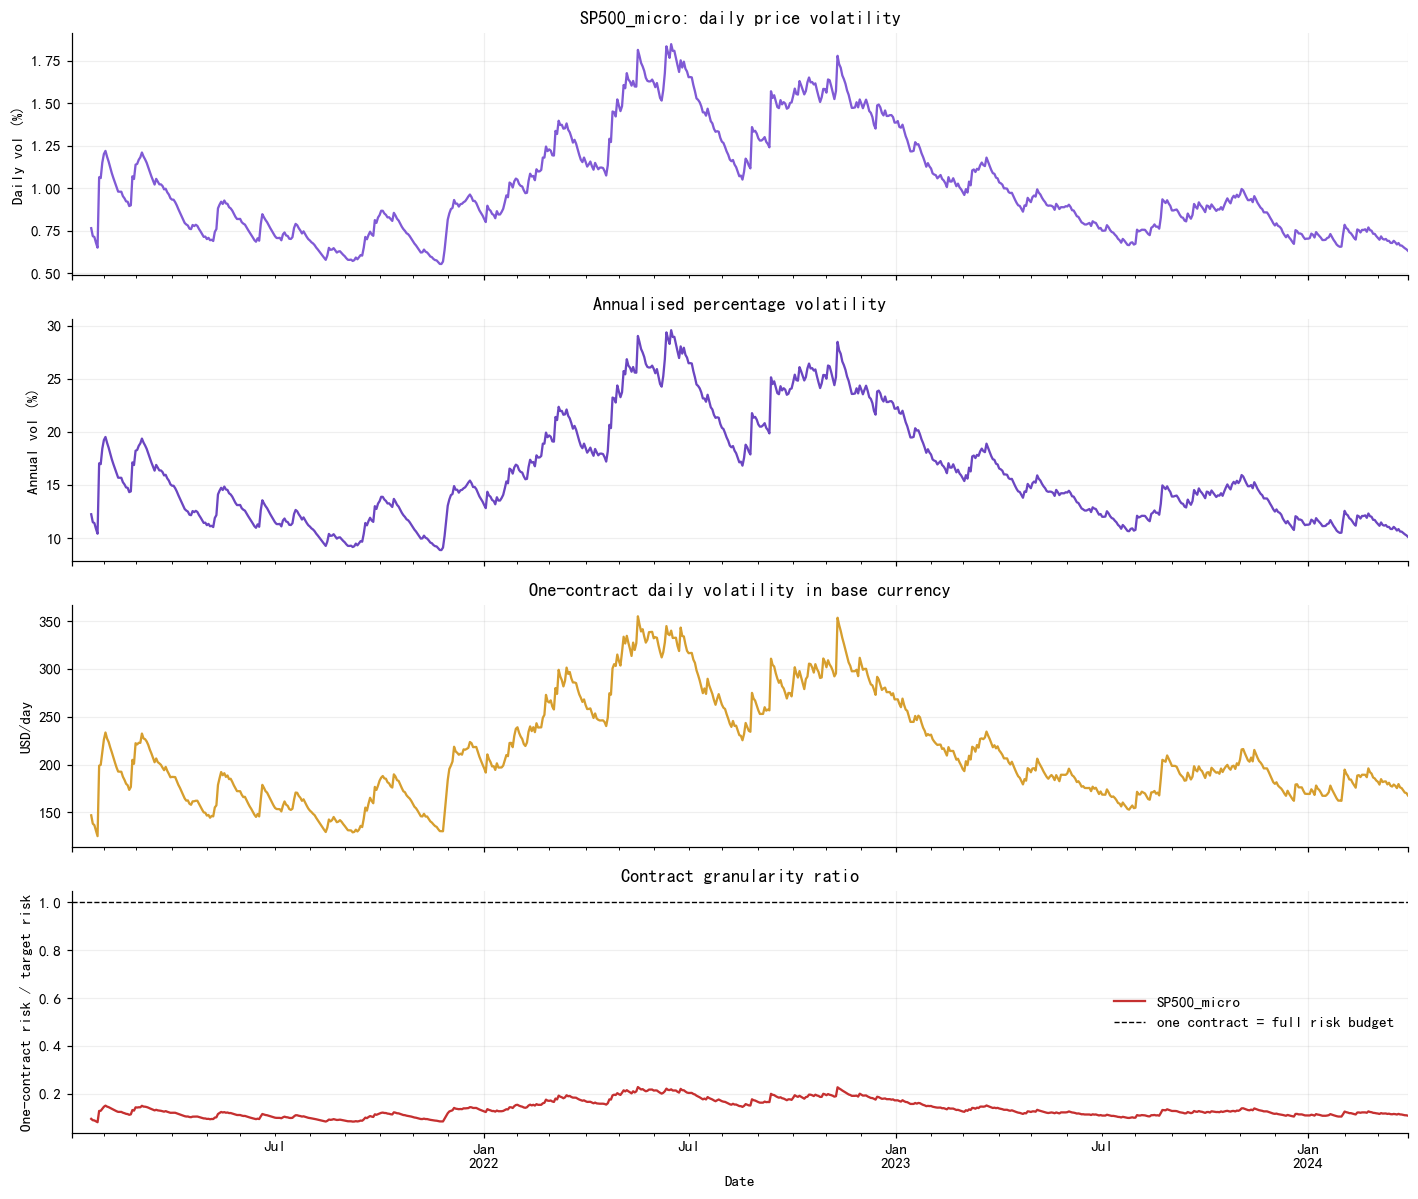

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
frames["daily_price_vol_pct"][FOCUS].plot(ax=axes[0], color="#805ad5")
axes[0].set(title=f"{FOCUS}: daily price volatility", ylabel="Daily vol (%)")
frames["annual_pct_vol_fraction"][FOCUS].mul(100).plot(ax=axes[1], color="#6b46c1")
axes[1].set(title="Annualised percentage volatility", ylabel="Annual vol (%)")
frames["base_currency_daily_vol"][FOCUS].plot(ax=axes[2], color="#d69e2e")
axes[2].set(title="One-contract daily volatility in base currency", ylabel="USD/day")
frames["contract_granularity_ratio"][FOCUS].plot(ax=axes[3], color="#c53030")
axes[3].axhline(1.0, color="black", ls="--", lw=.9, label="one contract = full risk budget")
axes[3].set(title="Contract granularity ratio", ylabel="One-contract risk / target risk", xlabel="Date")
axes[3].legend(); style_axes(axes); fig.tight_layout()

The key transformation is `contract value fraction × annual percentage volatility ÷ target portfolio volatility`. When this ratio rises, the account has fewer discrete choices even if the forecast is unchanged. This is risk exposure, not notional exposure.

## World 2 — Continuous mathematical portfolio

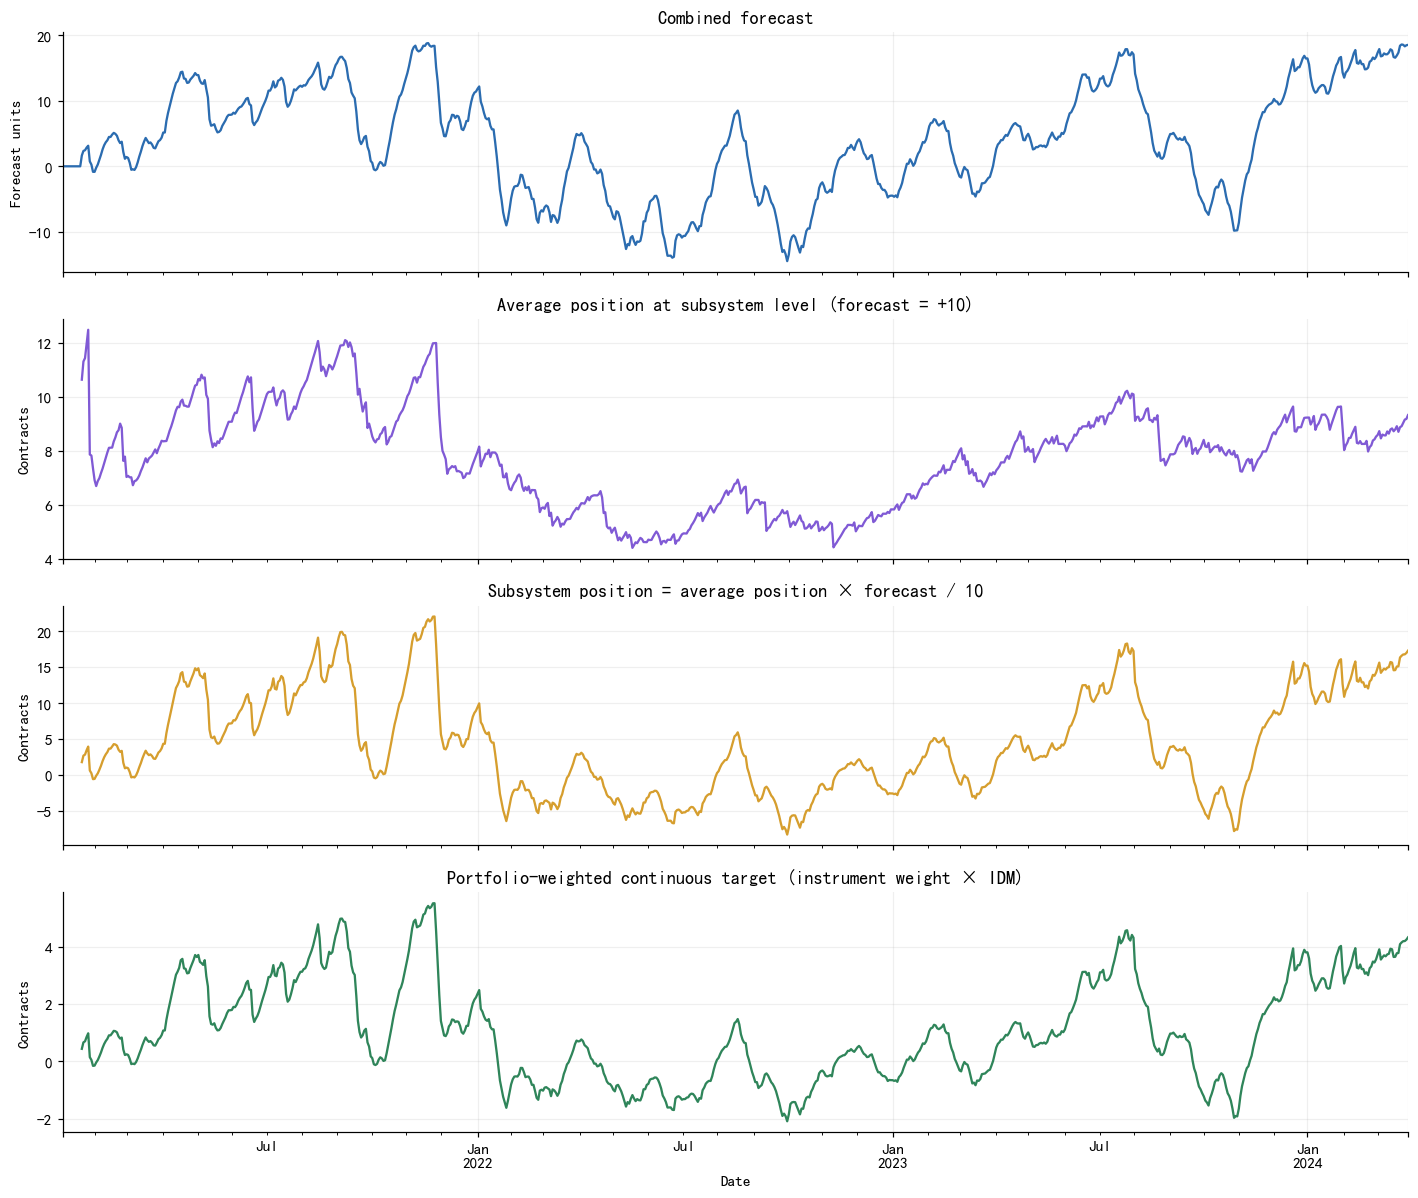

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
frames["combined_forecast"][FOCUS].plot(ax=axes[0], color="#2b6cb0")
axes[0].set(title="Combined forecast", ylabel="Forecast units")
frames["average_position"][FOCUS].plot(ax=axes[1], color="#805ad5")
axes[1].set(title="Average position at subsystem level (forecast = +10)", ylabel="Contracts")
frames["subsystem_position"][FOCUS].plot(ax=axes[2], color="#d69e2e")
axes[2].set(title="Subsystem position = average position × forecast / 10", ylabel="Contracts")
frames["continuous_position"][FOCUS].plot(ax=axes[3], color="#2f855a")
axes[3].set(title="Portfolio-weighted continuous target (instrument weight × IDM)", ylabel="Contracts", xlabel="Date")
style_axes(axes); fig.tight_layout()

These quantities must not be conflated. Volatility determines the average position; forecast tilts it into a subsystem position; instrument weight and diversification multiplier turn that into the ideal continuous portfolio target.

## World 3 — Continuous target → physical integer portfolio

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_33536\463515540.py:11: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.step(story.index, story["dynamic optimised"], where="post", color="#c53030", lw=1.5, label="dynamic optimised")


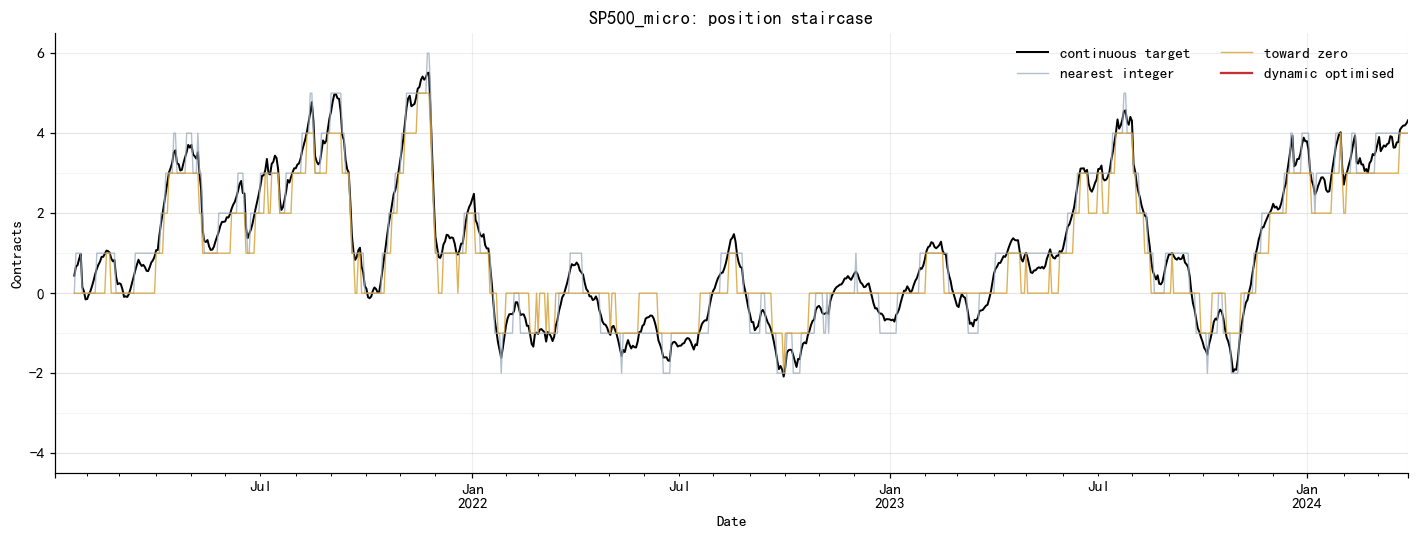

In [10]:
story = pd.DataFrame({
    "continuous target": frames["continuous_position"][FOCUS],
    "nearest integer": frames["nearest_integer_position"][FOCUS],
    "toward zero": frames["toward_zero_position"][FOCUS],
    "dynamic optimised": frames["optimised_position"][FOCUS],
})
fig, ax = plt.subplots(figsize=(13, 5))
story["continuous target"].plot(ax=ax, color="black", lw=1.3)
story["nearest integer"].plot(ax=ax, color="#a0aec0", lw=.9, alpha=.8)
story["toward zero"].plot(ax=ax, color="#d69e2e", lw=.9, alpha=.8)
ax.step(story.index, story["dynamic optimised"], where="post", color="#c53030", lw=1.5, label="dynamic optimised")
for level in range(-4, 5): ax.axhline(level, color="grey", alpha=.08, lw=.7)
ax.set(title=f"{FOCUS}: position staircase", ylabel="Contracts", xlabel="Date")
ax.legend(ncol=2); style_axes([ax]); fig.tight_layout()

Nearest and toward-zero rounding treat each market independently. Dynamic optimisation instead chooses the whole vector in covariance-aware weight space, penalises trades, and may retain yesterday's integer position even when today's continuous target moves.

## Price + actual position decisions

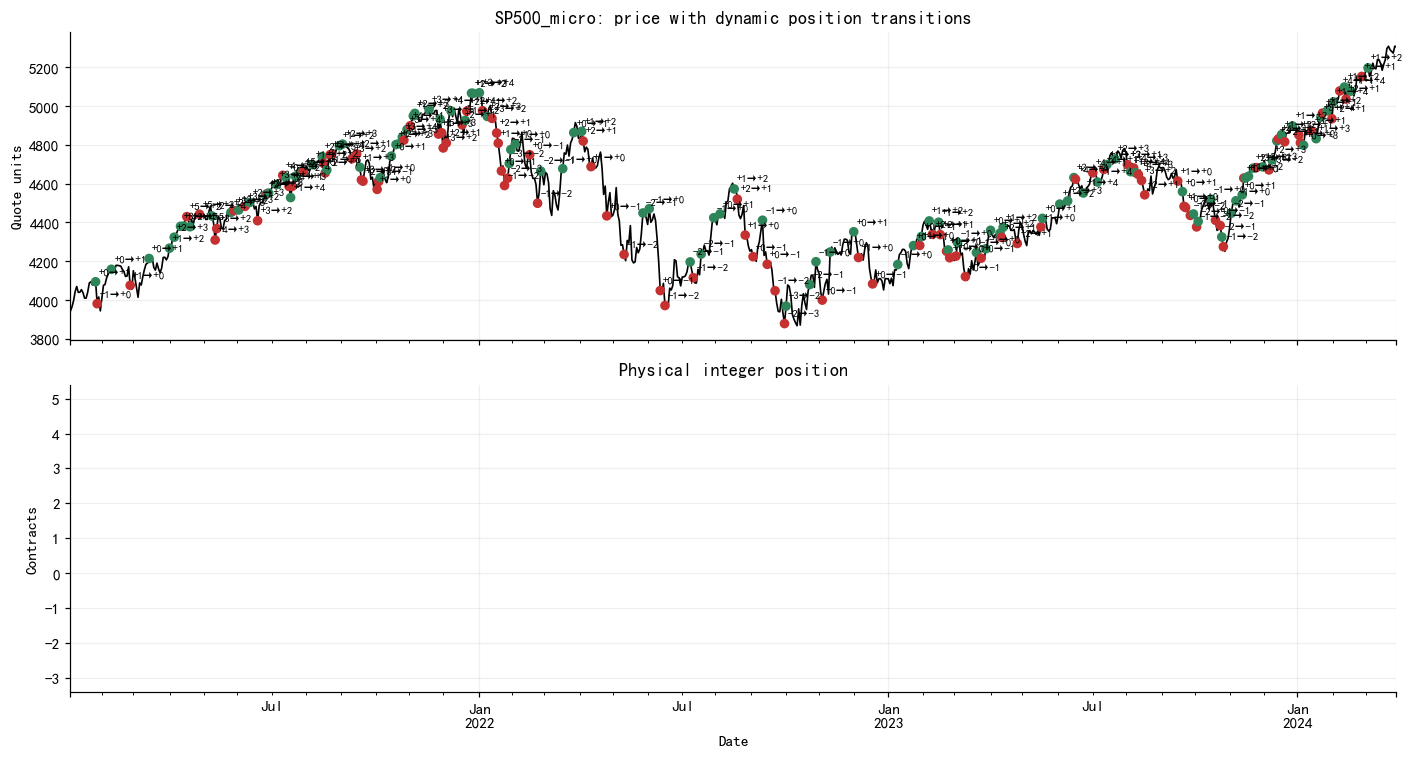

In [11]:
changes = frames["position_change"][FOCUS]
events_trade = changes[changes.ne(0)]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
frames["price"][FOCUS].plot(ax=axes[0], color="black", lw=1.1)
axes[0].scatter(events_trade.index, frames["price"].loc[events_trade.index, FOCUS],
                c=np.where(events_trade.gt(0), "#2f855a", "#c53030"), s=28, zorder=3)
for date, delta in events_trade.items():
    prior = frames["previous_integer_position"].at[date, FOCUS]
    new = frames["optimised_position"].at[date, FOCUS]
    axes[0].annotate(f"{prior:+.0f}→{new:+.0f}", (date, frames["price"].at[date, FOCUS]), fontsize=7, xytext=(2, 5), textcoords="offset points")
axes[0].set(title=f"{FOCUS}: price with dynamic position transitions", ylabel="Quote units")
axes[1].step(optimised.index, optimised[FOCUS], where="post", color="#2b6cb0")
axes[1].set(title="Physical integer position", ylabel="Contracts", xlabel="Date")
style_axes(axes); fig.tight_layout()

Markers identify actual state changes, not every continuous-target change. Long flat stretches are economically meaningful: the optimizer judged the benefit of a new integer vector insufficient after cost and buffer mechanics.

## Tracking error through time

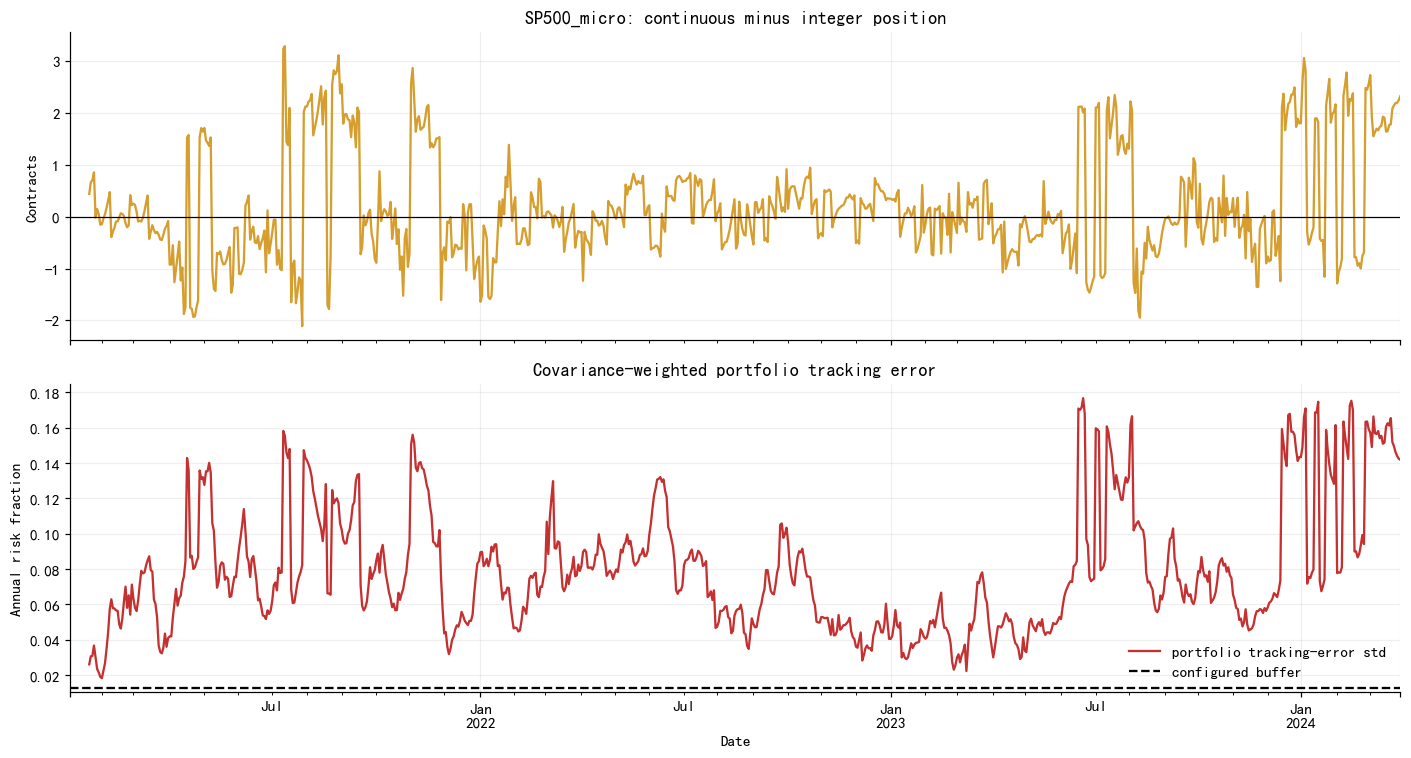

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
frames["instrument_tracking_error_contracts"][FOCUS].plot(ax=axes[0], color="#d69e2e")
axes[0].axhline(0, color="black", lw=.8)
axes[0].set(title=f"{FOCUS}: continuous minus integer position", ylabel="Contracts")
portfolio_tracking.plot(ax=axes[1], color="#c53030", label="portfolio tracking-error std")
axes[1].axhline(system.config.small_system["tracking_error_buffer"], color="black", ls="--", label="configured buffer")
axes[1].set(title="Covariance-weighted portfolio tracking error", ylabel="Annual risk fraction", xlabel="Date")
axes[1].legend(); style_axes(axes); fig.tight_layout()

Instrument contract gaps are intuitive but not additive. The lower panel reproduces the native covariance quadratic form, `sqrt((w_actual-w_ideal)' Σ (w_actual-w_ideal))`; this is the quantity compared with the initial no-trade buffer gate.

## World 4 — Event-study decision microscope

In [13]:
event_dates = find_decision_events(frames, FOCUS).dropna()
display(event_dates.to_frame())
snapshots = []
candidate_tables = {}
for label, date in event_dates.items():
    date = pd.Timestamp(date)
    snapshots.append(decision_snapshot(system, frames, FOCUS, date, portfolio_tracking).rename(label))
    previous = portfolioWeights(frames["previous_integer_position"].loc[date].to_dict())
    obj = objective_for_date(system, frames, date, previous)
    centre = int(frames["optimised_position"].at[date, FOCUS])
    candidate_tables[label] = candidate_objective_table(obj, FOCUS, range(centre - 2, centre + 3))
snapshot_table = pd.DataFrame(snapshots)
display(snapshot_table.style.format("{:.5g}"))
for label, table in candidate_tables.items():
    print(f"\n{label}: candidates for {FOCUS}")
    display(table.style.format("{:.6f}").highlight_min(subset=["total_objective"], color="#c6f6d5"))

,date
A_sub_one_target_held_zero,2023-11-14
B_zero_to_nonzero,2021-01-26
C_target_moves_no_trade,2024-03-21
D_reduction,2024-02-27
E_largest_continuous_integer_gap,2021-07-13


,price,combined_forecast,annual_vol_fraction,continuous_target_contracts,previous_integer_position,optimised_integer_position,one_contract_value_fraction,one_contract_value_base,cost_per_contract_base,shadow_cost,portfolio_tracking_error,tracking_error_buffer,target_portfolio_vol_fraction,capital
A_sub_one_target_held_zero,4628.2,2.6165,0.15261,0.47475,1,0,0.22571,22571,1.1124,50,0.048622,0.0125,0.25,1e+05
B_zero_to_nonzero,4094,3.1399,0.10415,0.97973,0,1,0.19232,19232,0.68843,50,0.029888,0.0125,0.25,1e+05
C_target_moves_no_trade,5307.2,18.415,0.1062,4.0838,2,2,0.26536,26536,1.2709,50,0.1518,0.0125,0.25,1e+05
D_reduction,5152,16.608,0.11723,3.4788,4,1,0.25451,25451,1.2029,50,0.16326,0.0125,0.25,1e+05
E_largest_continuous_integer_gap,4626,13.191,0.11516,3.2845,0,0,0.21796,21796,1.0505,50,0.15532,0.0125,0.25,1e+05



A_sub_one_target_held_zero: candidates for SP500_micro


,tracking_penalty,cost_penalty,constraint_penalty,total_objective
candidate_contracts,,,,
-2,0.130582,0.001669,0.000000,0.132251
-1,0.101662,0.001112,0.000000,0.102774
0,0.077405,0.000556,0.000000,0.077962
1,0.063413,0.000000,0.000000,0.063413
2,0.066512,0.000556,0.000000,0.067069



B_zero_to_nonzero: candidates for SP500_micro


...

,tracking_penalty,cost_penalty,constraint_penalty,total_objective
candidate_contracts,,,,
0,0.171913,0.001271,0.000000,0.173184
1,0.162969,0.000635,0.000000,0.163604
2,0.158594,0.000000,0.000000,0.158594
3,0.159166,0.000635,0.000000,0.159801
4,0.164633,0.001271,0.000000,0.165904



D_reduction: candidates for SP500_micro


,tracking_penalty,cost_penalty,constraint_penalty,total_objective
candidate_contracts,,,,
-1,0.196655,0.003007,0.000000,0.199662
0,0.171160,0.002406,0.000000,0.173566
1,0.147306,0.001804,0.000000,0.149110
2,0.126027,0.001203,0.000000,0.127229
3,0.108844,0.000601,0.000000,0.109445



E_largest_continuous_integer_gap: candidates for SP500_micro


,tracking_penalty,cost_penalty,constraint_penalty,total_objective
candidate_contracts,,,,
-2,0.166667,0.001050,0.000000,0.167717
-1,0.159125,0.000525,0.000000,0.159650
0,0.155318,0.000000,0.000000,0.155318
1,0.155520,0.000525,0.000000,0.156045
2,0.159717,0.001050,0.000000,0.160767


Candidate tables hold every other market at its prior integer position and vary only the focus contract. They are therefore a local microscope, while the native greedy search evaluates cross-market moves from its feasible start. The decomposition uses the optimizer's own methods, so shadow cost is already included in `cost_penalty`.

## One-contract granularity dashboard

,theoretical_contracts,one_contract_risk_usd,granularity_ratio,optimised_contracts
EUR_micro,-2.04,$787,0.03,-2
GOLD_micro,3.57,"$2,619",0.10,3
SP500_micro,4.32,"$2,682",0.11,2
CORN,-0.54,"$4,816",0.19,-1
NASDAQ_micro,1.54,"$5,118",0.20,1
US10,-0.28,"$6,167",0.25,0
CRUDE_W,0.40,"$14,169",0.57,0
SP500,0.43,"$26,784",1.07,1


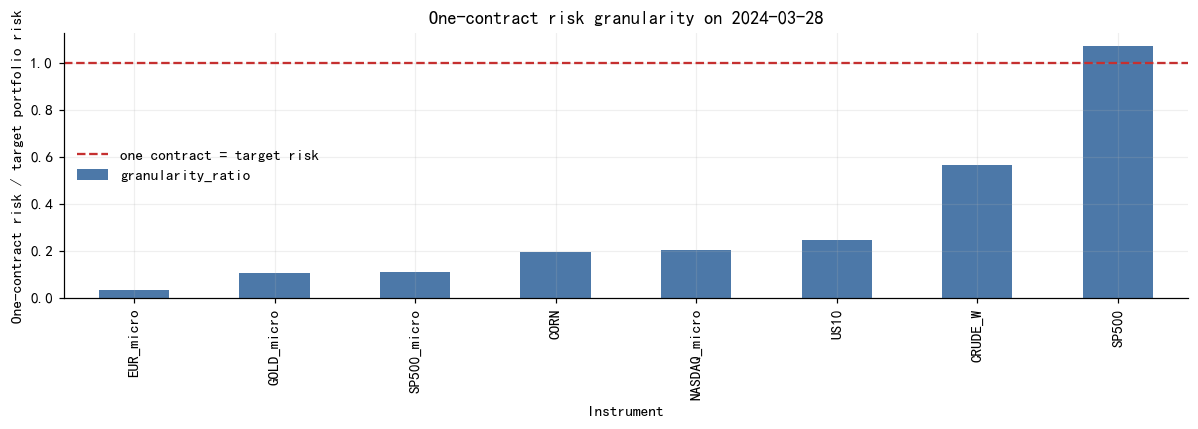

In [14]:
latest = frames["continuous_position"].index[-1]
granularity_table = pd.DataFrame({
    "theoretical_contracts": frames["continuous_position"].loc[latest],
    "one_contract_risk_usd": frames["one_contract_annual_risk_fraction"].loc[latest] * CAPITAL_BASE,
    "granularity_ratio": frames["contract_granularity_ratio"].loc[latest],
    "optimised_contracts": frames["optimised_position"].loc[latest],
}).sort_values("granularity_ratio")
ax = granularity_table["granularity_ratio"].plot.bar(figsize=(11, 4), color="#4c78a8")
ax.axhline(1.0, color="#c53030", ls="--", label="one contract = target risk")
ax.set(title=f"One-contract risk granularity on {latest.date()}", ylabel="One-contract risk / target portfolio risk", xlabel="Instrument")
ax.legend(); style_axes([ax]); plt.tight_layout()
display(granularity_table.style.format({"theoretical_contracts":"{:.2f}", "one_contract_risk_usd":"${:,.0f}", "granularity_ratio":"{:.2f}", "optimised_contracts":"{:.0f}"}))

Sorted granularity directly answers which markets the current account can finely discriminate. A high ratio does not force exclusion on every date, but it makes each allowed move a large portfolio-risk decision.

## Capital compatibility and portfolio phase changes

In [15]:
with Timer(timings, "capital_sweep_seconds"):
    capital_summary, positions_by_capital, tracking_by_capital = capital_sweep(
        system, frames, CAPITAL_SWEEP, cache_dir=CACHE_DIR,
        cache_prefix=cache_key(spec, "capital_sweep"),
    )
display(capital_summary.style.format({
    "annual_return":"{:.2%}", "annual_vol":"{:.2%}", "sharpe":"{:.2f}", "max_drawdown":"{:.2%}",
    "notional_turnover_per_year":"{:.2f}", "estimated_cost_fraction_per_year":"{:.2%}",
    "average_tracking_error":"{:.2%}", "tracking_error_p95":"{:.2%}",
    "average_active_markets":"{:.2f}", "median_active_markets":"{:.1f}",
    "pct_zero_positions":"{:.1%}", "average_gross_exposure":"{:.2f}",
    "diversification_active_fraction":"{:.1%}",
}))

,annual_return,annual_vol,sharpe,max_drawdown,contract_turnover_per_year,notional_turnover_per_year,estimated_cost_fraction_per_year,average_tracking_error,tracking_error_p95,average_active_markets,average_gross_exposure,position_changes,median_active_markets,pct_zero_positions,diversification_active_fraction
capital,,,,,,,,,,,,,,,
25000.000000,-6.36%,20.07%,-0.32,-44.23%,57.028436,45.45,0.32%,12.98%,19.86%,1.90,1.78,187.000000,2.0,76.2%,23.8%
100000.000000,5.14%,25.70%,0.20,-32.65%,251.402844,77.87,0.68%,7.93%,15.58%,4.63,2.92,742.000000,5.0,42.1%,57.9%
400000.000000,3.46%,26.82%,0.13,-40.49%,751.222749,61.04,0.65%,4.44%,7.94%,6.59,3.15,1829.000000,7.0,17.6%,82.4%


(<Figure size 1100x550 with 2 Axes>,
 <Axes: title={'center': 'Capital × instrument: mean absolute integer position'}, xlabel='Capital (USD)', ylabel='Instrument'>)

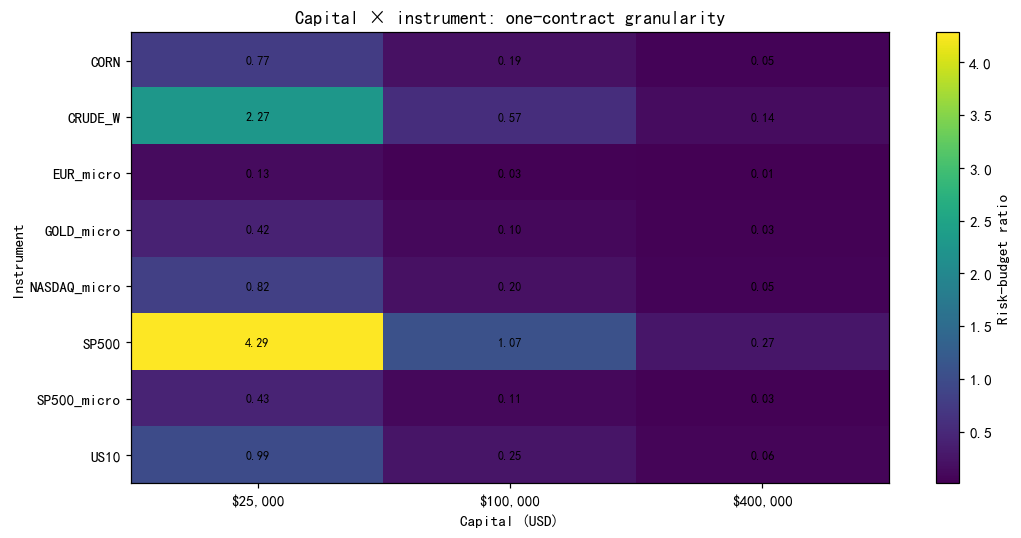

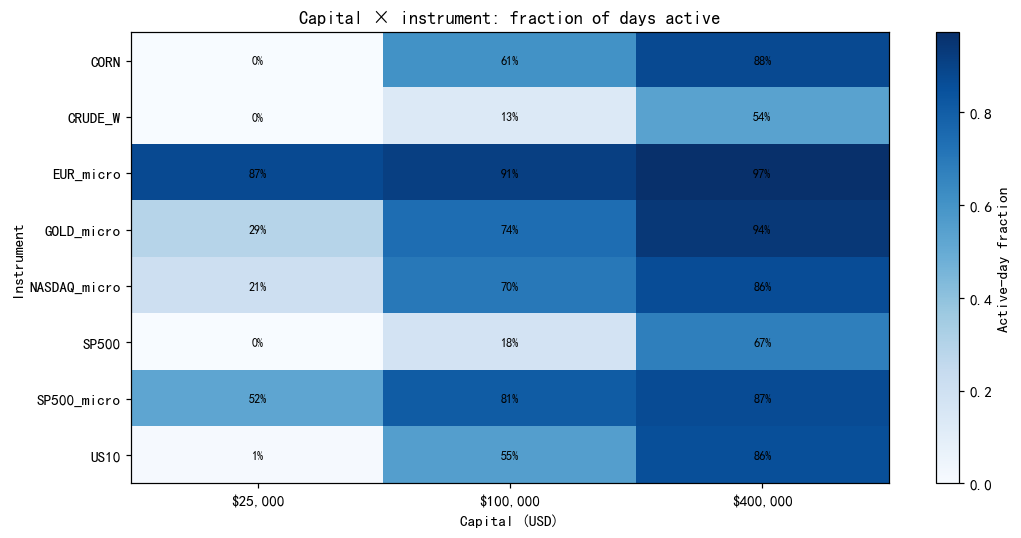

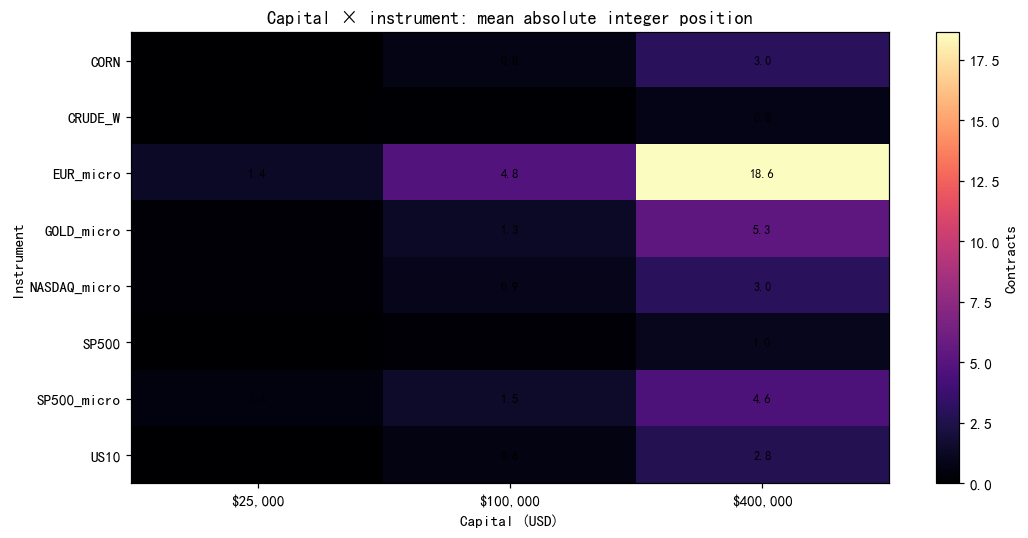

In [16]:
heatmaps = capital_heatmap_frames(frames, positions_by_capital, CAPITAL_BASE)
heatmap(heatmaps["granularity"], "Capital × instrument: one-contract granularity", "Risk-budget ratio", fmt=".2f")
heatmap(heatmaps["pct_active"], "Capital × instrument: fraction of days active", "Active-day fraction", cmap="Blues", fmt=".0%")
heatmap(heatmaps["mean_abs_position"], "Capital × instrument: mean absolute integer position", "Contracts", cmap="magma", fmt=".1f")

Capital changes the grid spacing, not the underlying ideal portfolio weights: continuous contracts scale up while per-contract weight scales down. The heatmaps reveal markets entering at different capital regimes and show that diversification improves through discrete phase changes rather than smooth scaling.

,active_markets,newly_active
capital,,
25000.0,5,"EUR_micro, GOLD_micro, NASDAQ_micro, SP500_mic..."
100000.0,8,"CORN, CRUDE_W, SP500"
400000.0,8,—


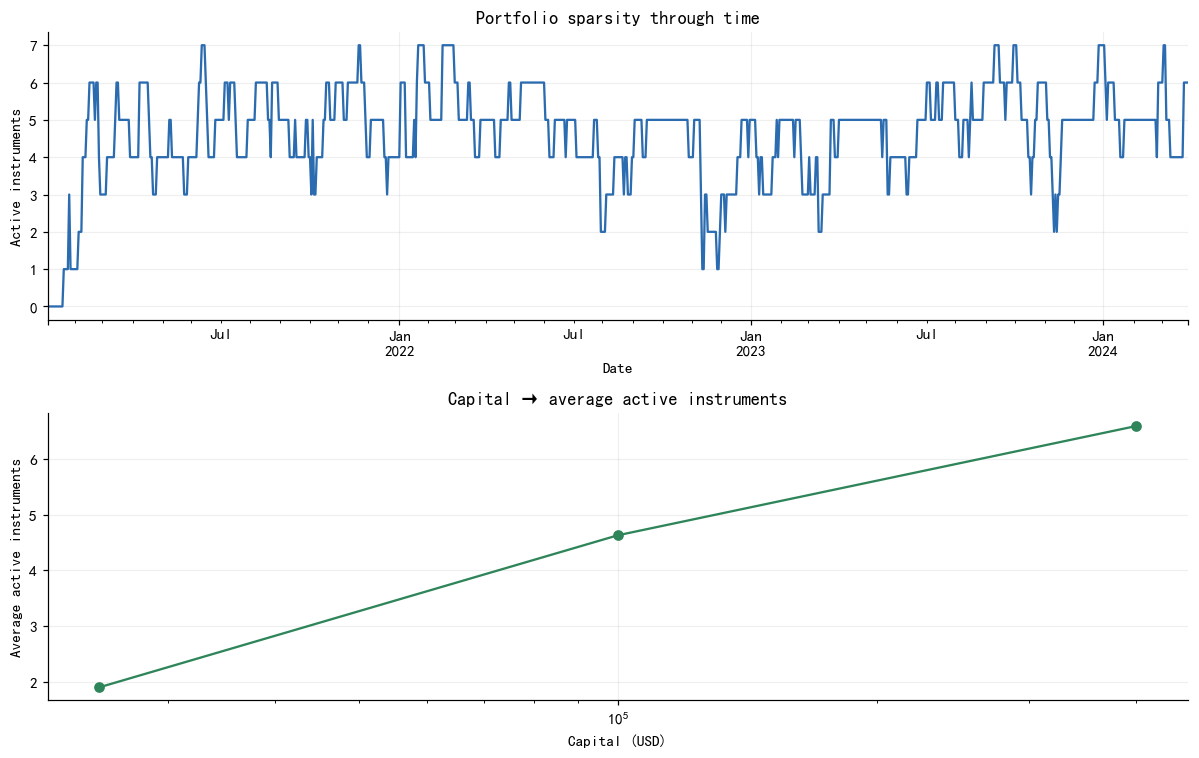

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
active_base = optimised.ne(0).sum(axis=1)
active_base.plot(ax=axes[0], color="#2b6cb0")
axes[0].set(title="Portfolio sparsity through time", ylabel="Active instruments", xlabel="Date")
capital_summary["average_active_markets"].plot(ax=axes[1], marker="o", color="#2f855a")
axes[1].set_xscale("log")
axes[1].set(title="Capital → average active instruments", ylabel="Average active instruments", xlabel="Capital (USD)")
style_axes(axes); fig.tight_layout()
display(phase_transition_table(positions_by_capital))

## Capital staircase

,continuous_contracts,optimised_contracts
25000.0,0.752,1.0
100000.0,3.008,1.0
400000.0,12.031,9.0


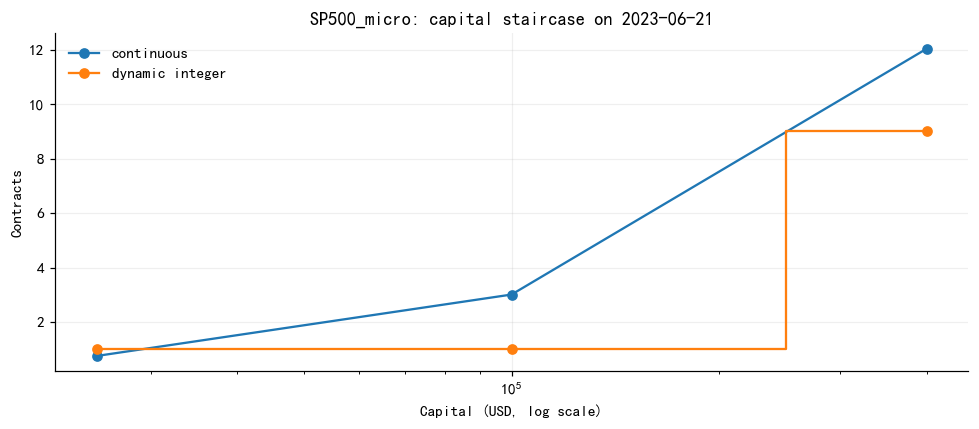

In [18]:
representative_date = portfolio_tracking.idxmax()
capitals_sorted = sorted(positions_by_capital)
capital_stair = pd.DataFrame(index=capitals_sorted)
capital_stair["continuous_contracts"] = [
    frames["continuous_position"].at[representative_date, FOCUS] * capital / CAPITAL_BASE
    for capital in capitals_sorted
]
capital_stair["optimised_contracts"] = [positions_by_capital[capital].at[representative_date, FOCUS] for capital in capitals_sorted]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(capital_stair.index, capital_stair["continuous_contracts"], marker="o", label="continuous")
ax.step(capital_stair.index, capital_stair["optimised_contracts"], where="mid", marker="o", label="dynamic integer")
ax.set_xscale("log")
ax.set(title=f"{FOCUS}: capital staircase on {representative_date.date()}", xlabel="Capital (USD, log scale)", ylabel="Contracts")
ax.legend(); style_axes([ax]); fig.tight_layout()
display(capital_stair.round(3))

The ideal position grows smoothly with capital; the executable position changes only when an integer vector becomes worthwhile. Account size is therefore a structural implementation variable, not just a scalar applied to P&L.

## Micro versus full-size case study

In [19]:
pairs = [("SP500", "SP500_micro")]
pair_rows = []
for full, micro in pairs:
    for instrument in (full, micro):
        pair_rows.append({
            "instrument": instrument,
            "multiplier": frames["contract_multiplier"].at[latest, instrument],
            "one_contract_risk_usd": frames["one_contract_annual_risk_fraction"].at[latest, instrument] * CAPITAL_BASE,
            "granularity_ratio": frames["contract_granularity_ratio"].at[latest, instrument],
            "continuous_target": frames["continuous_position"].at[latest, instrument],
            "integer_target": frames["optimised_position"].at[latest, instrument],
            "active_day_fraction": frames["optimised_position"][instrument].ne(0).mean(),
            "mean_abs_tracking_contracts": frames["instrument_tracking_error_contracts"][instrument].abs().mean(),
        })
micro_case = pd.DataFrame(pair_rows).set_index("instrument")
display(micro_case.style.format({"multiplier":"{:,.1f}", "one_contract_risk_usd":"${:,.0f}", "granularity_ratio":"{:.2f}", "continuous_target":"{:.2f}", "integer_target":"{:.0f}", "active_day_fraction":"{:.1%}", "mean_abs_tracking_contracts":"{:.2f}"}))

,multiplier,one_contract_risk_usd,granularity_ratio,continuous_target,integer_target,active_day_fraction,mean_abs_tracking_contracts
instrument,,,,,,,
SP500,50.0,"$26,784",1.07,0.43,1,17.5%,0.20
SP500_micro,5.0,"$2,682",0.11,4.32,2,80.6%,0.75


The micro contract's smaller multiplier reduces the risk jump from a single contract and normally increases position activity. The comparison is empirical: it reports realised tracking and activity, not the generic claim that micro contracts are always preferable.

## Naive rounding baselines and portfolio-level comparison

In [20]:
method_positions = {
    "Continuous": frames["continuous_position"],
    "Nearest integer": frames["nearest_integer_position"],
    "Toward zero": frames["toward_zero_position"],
    "Dynamic": frames["optimised_position"],
}
tracking_by_method = {
    "Continuous": pd.Series(0.0, index=optimised.index),
    "Nearest integer": tracking_error_series(system, frames, method_positions["Nearest integer"]),
    "Toward zero": tracking_error_series(system, frames, method_positions["Toward zero"]),
    "Dynamic": portfolio_tracking,
}
comparison = pd.DataFrame({
    name: method_metrics(frames, positions, CAPITAL_BASE, tracking_by_method[name])
    for name, positions in method_positions.items()
}).T
display(comparison.style.format({
    "annual_return":"{:.2%}", "annual_vol":"{:.2%}", "sharpe":"{:.2f}", "max_drawdown":"{:.2%}",
    "notional_turnover_per_year":"{:.2f}", "estimated_cost_fraction_per_year":"{:.2%}",
    "average_tracking_error":"{:.2%}", "tracking_error_p95":"{:.2%}",
    "average_active_markets":"{:.2f}", "average_gross_exposure":"{:.2f}",
}))

,annual_return,annual_vol,sharpe,max_drawdown,contract_turnover_per_year,notional_turnover_per_year,estimated_cost_fraction_per_year,average_tracking_error,tracking_error_p95,average_active_markets,average_gross_exposure,position_changes
Continuous,2.49%,25.77%,0.10,-36.95%,246.433281,72.84,0.93%,0.00%,0.00%,8.00,3.13,6752.000000
Nearest integer,4.62%,22.54%,0.21,-28.21%,246.327014,67.18,0.97%,7.66%,12.17%,4.59,2.63,894.000000
Toward zero,1.28%,14.41%,0.09,-22.23%,195.867299,46.39,0.53%,10.97%,16.46%,3.06,1.66,725.000000
Dynamic,5.14%,25.70%,0.20,-32.65%,251.402844,77.87,0.68%,7.93%,15.58%,4.63,2.92,742.000000


These baselines are diagnostics, not production recommendations. Continuous positions define the mathematical target but are untradeable; naive methods can have low pointwise error while ignoring covariance, prior positions, transaction cost and the portfolio-level no-trade region.

## Risk contribution: ideal versus integer

,ideal_risk_contribution,integer_risk_contribution
CRUDE_W,-0.15%,0.00%
GOLD_micro,-0.05%,-0.08%
US10,0.42%,0.00%
EUR_micro,0.85%,0.00%
CORN,1.36%,0.00%
SP500_micro,6.25%,1.65%
SP500,6.27%,27.47%
NASDAQ_micro,9.90%,3.24%


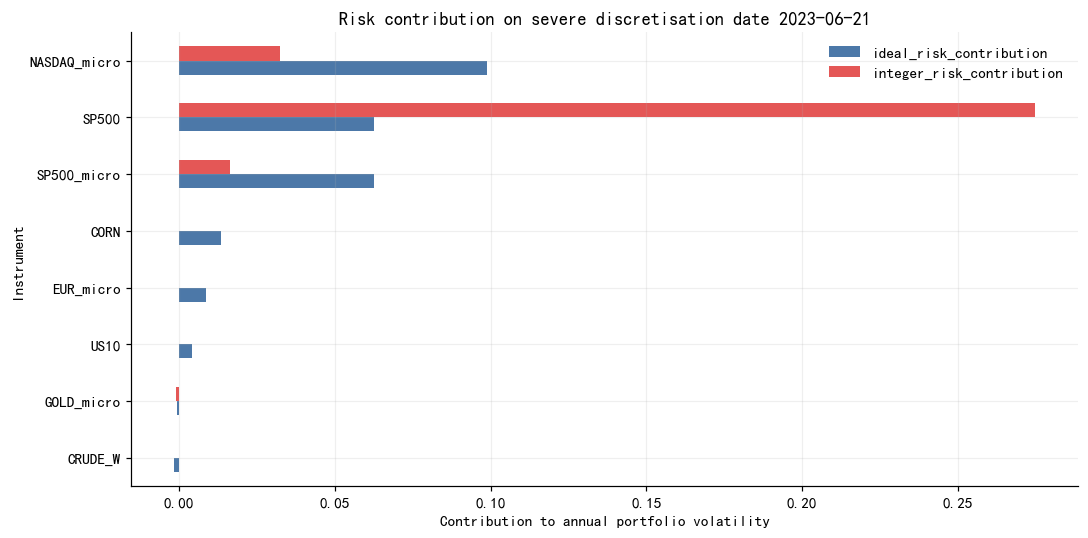

In [21]:
severe_date = portfolio_tracking.idxmax()
risk_contrib = risk_contributions(system, frames, optimised, severe_date)
ax = risk_contrib.plot.barh(figsize=(10, 5), color=["#4c78a8", "#e45756"])
ax.set(title=f"Risk contribution on severe discretisation date {severe_date.date()}", xlabel="Contribution to annual portfolio volatility", ylabel="Instrument")
style_axes([ax]); plt.tight_layout()
display(risk_contrib.style.format("{:.2%}"))

Integer implementation can reorder the risk structure rather than merely shrink every ideal exposure. Contributions can also be negative when an instrument hedges the rest of the portfolio; covariance is why independent rounding is not generally optimal.

## Correlation, shrinkage and covariance

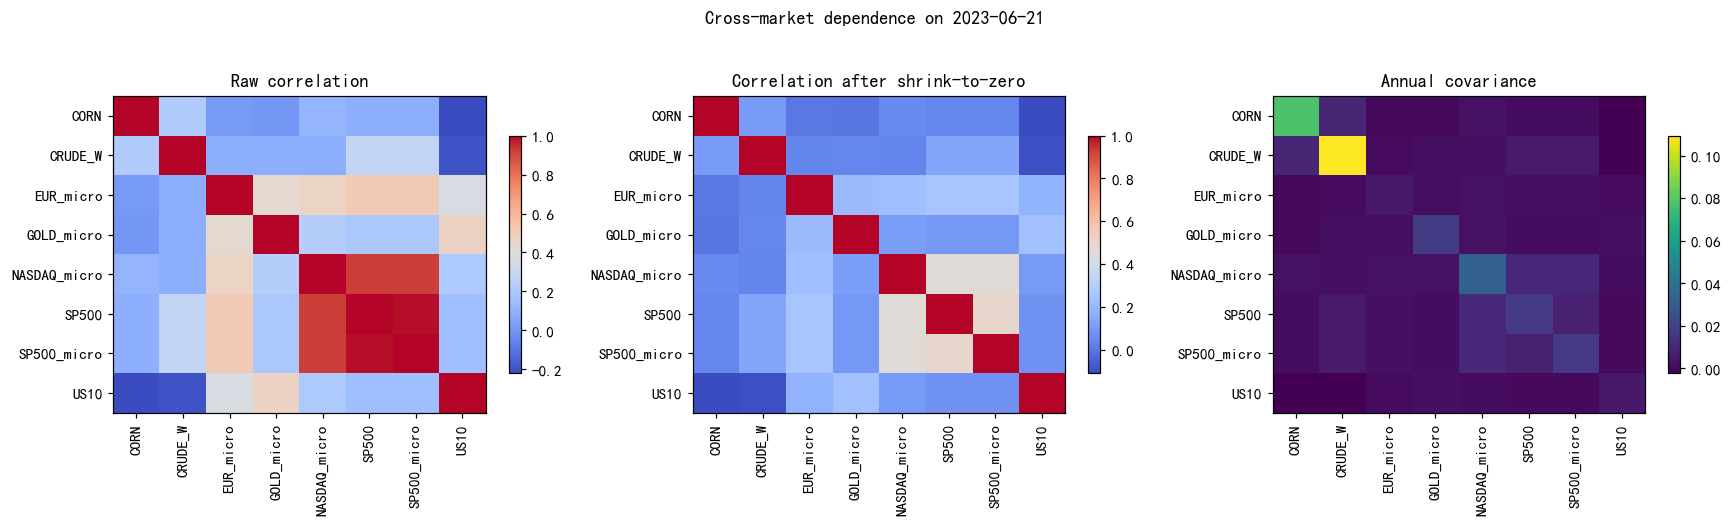

In [22]:
raw_corr, shrunk_corr, covariance = covariance_and_correlation_frames(system, severe_date)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, data, title, cmap in zip(
    axes, [raw_corr, shrunk_corr, covariance],
    ["Raw correlation", "Correlation after shrink-to-zero", "Annual covariance"],
    ["coolwarm", "coolwarm", "viridis"],
):
    image = ax.imshow(data.to_numpy(), cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(data)), data.columns, rotation=90)
    ax.set_yticks(range(len(data)), data.index)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=.75)
fig.suptitle(f"Cross-market dependence on {severe_date.date()}", y=1.03)
fig.tight_layout()

The configured shrinkage value is the weight placed on a zero-off-diagonal prior: 0 keeps raw correlations, 1 discards all cross-correlations, and 0.5 blends them equally. Covariance then combines the shrunk correlations with each market's annual percentage volatility.

## Economic-implementation sensitivity


tracking_error_buffer


,average_tracking_error,notional_turnover_per_year,estimated_cost_fraction_per_year,position_changes
tracking_error_buffer,,,,
0.000000,7.87%,78.91,0.69%,784
0.012500,7.93%,77.87,0.68%,742
0.025000,8.21%,68.36,0.62%,596



shadow_cost


,average_tracking_error,notional_turnover_per_year,estimated_cost_fraction_per_year,position_changes
shadow_cost,,,,
0.000000,7.85%,104.39,1.13%,980
50.000000,7.93%,77.87,0.68%,742
100.000000,8.28%,64.04,0.48%,603



cost_multiplier


,average_tracking_error,notional_turnover_per_year,estimated_cost_fraction_per_year,position_changes
cost_multiplier,,,,
0.500000,7.85%,89.82,0.84%,818
1.000000,7.93%,77.87,0.68%,742
2.000000,8.28%,64.04,0.48%,603



correlation_shrinkage


,average_tracking_error,notional_turnover_per_year,estimated_cost_fraction_per_year,position_changes
correlation_shrinkage,,,,
0.000000,6.41%,85.41,0.80%,853
0.500000,7.93%,77.87,0.68%,742
1.000000,7.89%,44.96,0.52%,525


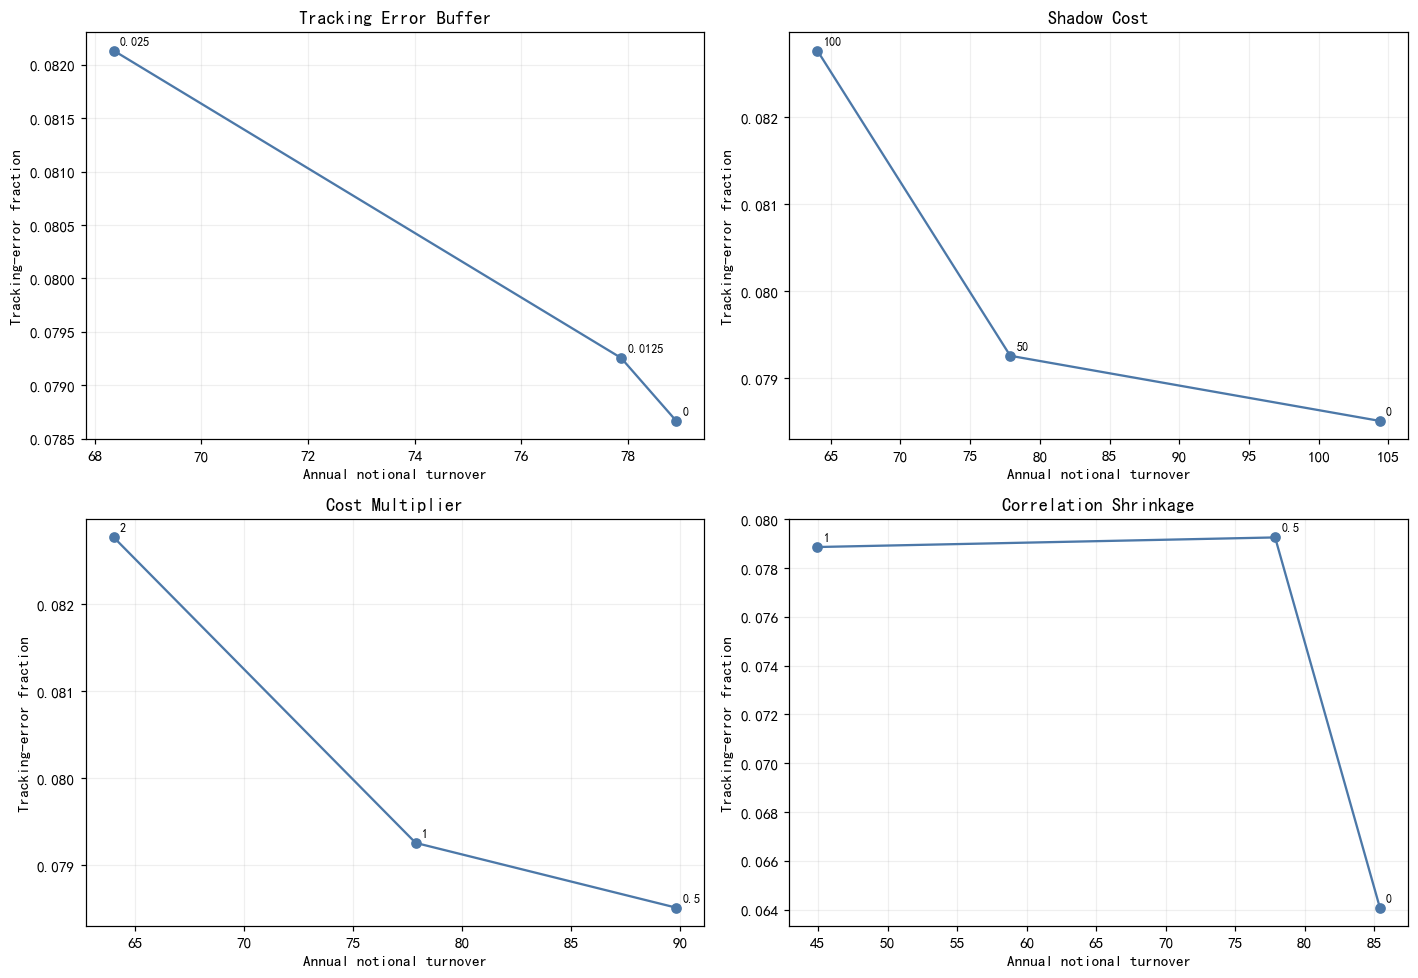

In [23]:
with Timer(timings, "parameter_sweeps_seconds"):
    sweep_results = {
        "tracking_error_buffer": parameter_sweep(system, frames, "tracking_error_buffer", TRACKING_ERROR_BUFFER_VALUES, cache_dir=CACHE_DIR),
        "shadow_cost": parameter_sweep(system, frames, "shadow_cost", SHADOW_COST_VALUES, cache_dir=CACHE_DIR),
        "cost_multiplier": parameter_sweep(system, frames, "cost_multiplier", COST_MULTIPLIER_VALUES, cache_dir=CACHE_DIR),
        "correlation_shrinkage": parameter_sweep(system, frames, "correlation_shrinkage", CORRELATION_SHRINKAGE_VALUES, cache_dir=CACHE_DIR),
    }
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (parameter, result) in zip(axes.ravel(), sweep_results.items()):
    ax.plot(result["notional_turnover_per_year"], result["average_tracking_error"], marker="o", color="#4c78a8")
    for parameter_value, row in result.iterrows():
        ax.annotate(f"{parameter_value:g}", (row["notional_turnover_per_year"], row["average_tracking_error"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set(title=parameter.replace("_", " ").title(), xlabel="Annual notional turnover", ylabel="Tracking-error fraction")
    ax.grid(True, alpha=.2)
fig.tight_layout()
for parameter, result in sweep_results.items():
    print(f"\n{parameter}")
    display(result[["average_tracking_error", "notional_turnover_per_year", "estimated_cost_fraction_per_year", "position_changes"]].style.format({
        "average_tracking_error":"{:.2%}", "notional_turnover_per_year":"{:.2f}", "estimated_cost_fraction_per_year":"{:.2%}", "position_changes":"{:.0f}"}))

Buffer acts twice: it can stop optimisation when the prior portfolio is close enough, and it scales/rounds the move toward the raw greedy result. Shadow cost multiplies the cost term inside the objective; cost multiplier scales the native cost estimate before that shadow multiplier. Sensitivities need not be monotone because integer and cross-market choices change at thresholds.

## Capital × tracking-error-buffer experiment

(<Figure size 880x418 with 2 Axes>,
 <Axes: title={'center': 'Capital × buffer: annual notional turnover'}, xlabel='Capital (USD)', ylabel='Instrument'>)

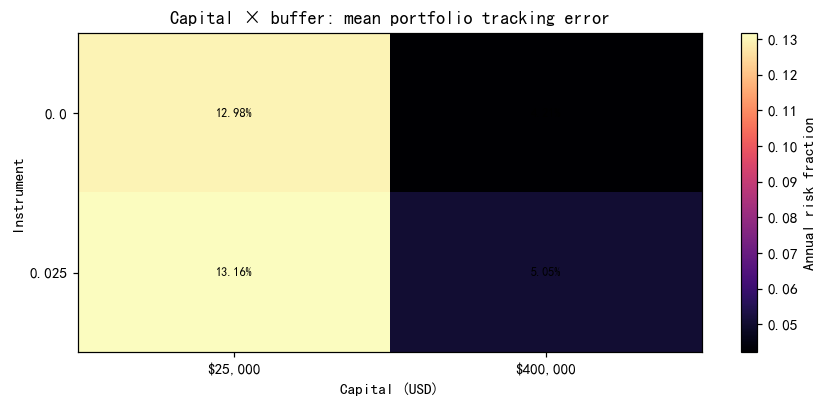

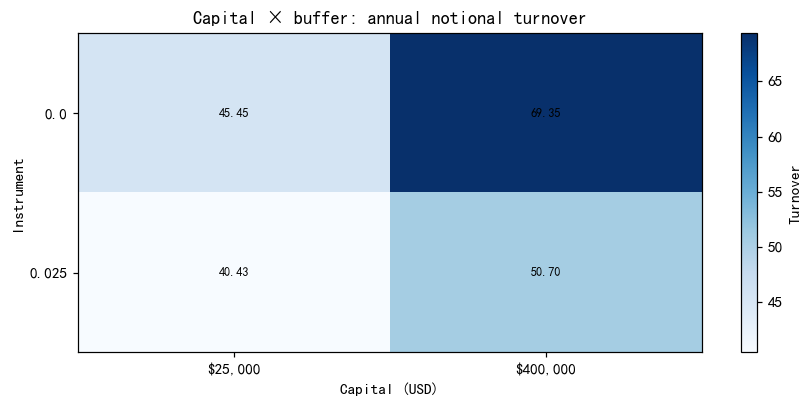

In [24]:
grid_capitals = [CAPITAL_SWEEP[0], CAPITAL_SWEEP[-1]] if QUICK_MODE else CAPITAL_SWEEP
grid_buffers = [TRACKING_ERROR_BUFFER_VALUES[0], TRACKING_ERROR_BUFFER_VALUES[-1]] if QUICK_MODE else TRACKING_ERROR_BUFFER_VALUES
grid_tracking = pd.DataFrame(index=grid_buffers, columns=grid_capitals, dtype=float)
grid_turnover = grid_tracking.copy()
with Timer(timings, "two_dimensional_sweep_seconds"):
    for buffer_value in grid_buffers:
        for capital in grid_capitals:
            pos = run_optimisation(system, frames, capital=capital, tracking_error_buffer=buffer_value,
                                   cache_dir=CACHE_DIR, cache_id=f"2d_cap_{int(capital)}_buffer_{buffer_value:g}")
            track = tracking_error_series(system, frames, pos, capital=capital)
            grid_tracking.at[buffer_value, capital] = track.mean()
            scaled_per_contract = frames["per_contract_value_fraction"] * CAPITAL_BASE / capital
            grid_turnover.at[buffer_value, capital] = (pos.diff().abs().fillna(pos.abs()) * scaled_per_contract).sum(axis=1).mean() * 252
heatmap(grid_tracking, "Capital × buffer: mean portfolio tracking error", "Annual risk fraction", cmap="magma", fmt=".2%", figsize=(8, 3.8))
heatmap(grid_turnover, "Capital × buffer: annual notional turnover", "Turnover", cmap="Blues", fmt=".2f", figsize=(8, 3.8))

This small two-dimensional grid shows interaction rather than treating knobs independently. The same buffer represents a different practical no-trade region when contract weights shrink with capital.

## Turnover and trades

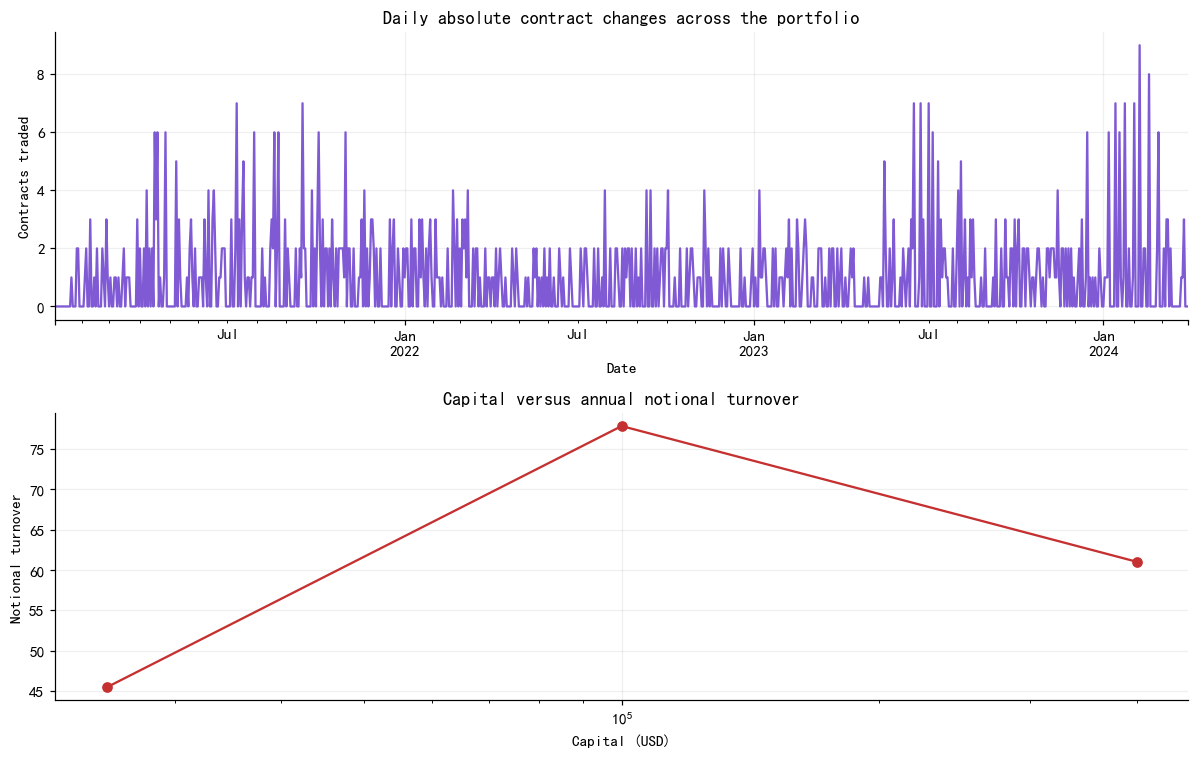

In [25]:
daily_contract_changes = optimised.diff().abs().fillna(optimised.abs()).sum(axis=1)
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
daily_contract_changes.plot(ax=axes[0], color="#805ad5")
axes[0].set(title="Daily absolute contract changes across the portfolio", ylabel="Contracts traded", xlabel="Date")
capital_summary["notional_turnover_per_year"].plot(ax=axes[1], marker="o", color="#c53030")
axes[1].set_xscale("log")
axes[1].set(title="Capital versus annual notional turnover", ylabel="Notional turnover", xlabel="Capital (USD)")
style_axes(axes); fig.tight_layout()

Contract turnover counts physical units and is not comparable across instruments. Notional turnover weights trades by contract value/capital; the objective itself uses cost-aware weight changes, so both views are useful but answer different questions.

## Computable-intuition summary dashboard

In [26]:
dynamic_metrics = comparison.loc["Dynamic"]
headline = pd.Series({
    "capital_usd": CAPITAL_BASE,
    "median_latest_granularity_ratio": frames["contract_granularity_ratio"].iloc[-1].median(),
    "average_active_instruments": optimised.ne(0).sum(axis=1).mean(),
    "average_tracking_error": portfolio_tracking.mean(),
    "tracking_error_p95": portfolio_tracking.quantile(.95),
    "annual_position_changes": frames["position_change"].ne(0).sum().sum() / (len(optimised) / 252),
    "annual_notional_turnover": dynamic_metrics["notional_turnover_per_year"],
    "realised_annual_vol": dynamic_metrics["annual_vol"],
    "estimated_annual_cost_fraction": dynamic_metrics["estimated_cost_fraction_per_year"],
    "annual_return": dynamic_metrics["annual_return"],
    "sharpe": dynamic_metrics["sharpe"],
    "max_drawdown": dynamic_metrics["max_drawdown"],
}, name="value")
display(headline.to_frame().style.format("{:.4g}"))
display(comparison[["annual_return", "annual_vol", "sharpe", "max_drawdown", "notional_turnover_per_year", "estimated_cost_fraction_per_year", "average_tracking_error", "average_active_markets"]])

,value
capital_usd,1e+05
median_latest_granularity_ratio,0.1987
average_active_instruments,4.63
average_tracking_error,0.07926
tracking_error_p95,0.1558
annual_position_changes,221.5
annual_notional_turnover,77.87
realised_annual_vol,0.257
estimated_annual_cost_fraction,0.0068
annual_return,0.05139


,annual_return,annual_vol,sharpe,max_drawdown,notional_turnover_per_year,estimated_cost_fraction_per_year,average_tracking_error,average_active_markets
Continuous,0.024874,0.257743,0.096506,-0.369469,72.844449,0.009280,0.000000,8.000000
Nearest integer,0.046211,0.225398,0.205018,-0.282056,67.176557,0.009687,0.076589,4.594787
Toward zero,0.012815,0.144132,0.088914,-0.222254,46.387741,0.005328,0.109742,3.062796
Dynamic,0.051386,0.256972,0.199967,-0.326544,77.874247,0.006800,0.079255,4.630332


## What did we learn?

In [27]:
latest_gran = frames["contract_granularity_ratio"].iloc[-1]
small_cap, large_cap = min(positions_by_capital), max(positions_by_capital)
micro_ratio = micro_case.loc["SP500_micro", "granularity_ratio"]
full_ratio = micro_case.loc["SP500", "granularity_ratio"]
dynamic_vs_nearest_te = comparison.loc["Dynamic", "average_tracking_error"] - comparison.loc["Nearest integer", "average_tracking_error"]
buffer_sweep = sweep_results["tracking_error_buffer"]
shadow_sweep = sweep_results["shadow_cost"]
answers = pd.DataFrame({"evidence-backed answer": {
    "Q1 What makes a market too large?": f"One-contract risk versus the portfolio risk budget. Latest ratios range {latest_gran.min():.2f}–{latest_gran.max():.2f}.",
    "Q2 Why does diversification worsen as capital falls?": f"Average active markets move from {capital_summary.loc[small_cap, 'average_active_markets']:.2f} at ${small_cap:,.0f} to {capital_summary.loc[large_cap, 'average_active_markets']:.2f} at ${large_cap:,.0f}.",
    "Q3 Why not simply round?": f"Nearest rounding has {comparison.loc['Nearest integer','average_tracking_error']:.2%} average covariance-weighted error and {comparison.loc['Nearest integer','notional_turnover_per_year']:.2f} turnover; dynamic jointly prices state and trading.",
    "Q4 Why does covariance matter?": "The risk-contribution table contains cross-market hedging/reinforcement; the objective measures a quadratic portfolio gap, not independent contract errors.",
    "Q5 What does transaction cost change?": f"Across cost multipliers, position changes range {sweep_results['cost_multiplier']['position_changes'].min():.0f}–{sweep_results['cost_multiplier']['position_changes'].max():.0f}.",
    "Q6 What does the buffer do?": f"Across tested buffers, annual turnover ranges {buffer_sweep['notional_turnover_per_year'].min():.2f}–{buffer_sweep['notional_turnover_per_year'].max():.2f} while average tracking error ranges {buffer_sweep['average_tracking_error'].min():.2%}–{buffer_sweep['average_tracking_error'].max():.2%}.",
    "Q7 What does shadow cost do?": f"Across tested values, position changes range {shadow_sweep['position_changes'].min():.0f}–{shadow_sweep['position_changes'].max():.0f}; it changes the objective, not the market forecast.",
    "Q8 How much do micro contracts help?": f"S&P micro/full latest granularity ratio is {micro_ratio:.2f}/{full_ratio:.2f}, a {full_ratio/micro_ratio:.1f}× refinement.",
    "Q9 When does discrete optimisation matter less?": f"At ${large_cap:,.0f}, average tracking error is {capital_summary.loc[large_cap,'average_tracking_error']:.2%} versus {capital_summary.loc[small_cap,'average_tracking_error']:.2%} at ${small_cap:,.0f}.",
    "Q10 What is the dominant small-account constraint?": f"In this experiment the observable bottleneck is contract indivisibility: median latest one-contract risk unit is {latest_gran.median():.2f} of the target risk budget; forecasts and volatility determine the ideal target but cannot create smaller contracts.",
}})
display(answers)

,evidence-backed answer
Q1 What makes a market too large?,One-contract risk versus the portfolio risk bu...
Q10 What is the dominant small-account constraint?,In this experiment the observable bottleneck i...
Q2 Why does diversification worsen as capital falls?,"Average active markets move from 1.90 at $25,0..."
Q3 Why not simply round?,Nearest rounding has 7.66% average covariance-...
Q4 Why does covariance matter?,The risk-contribution table contains cross-mar...
Q5 What does transaction cost change?,"Across cost multipliers, position changes rang..."
Q6 What does the buffer do?,"Across tested buffers, annual turnover ranges ..."
Q7 What does shadow cost do?,"Across tested values, position changes range 6..."
Q8 How much do micro contracts help?,S&P micro/full latest granularity ratio is 0.1...
Q9 When does discrete optimisation matter less?,"At $400,000, average tracking error is 4.44% v..."


## Automated sanity and reproducibility checks

In [28]:
checks = sanity_checks(frames, optimised, positions_by_capital)
checks["native_stage_factory_matches_replay_tail"] = compare_native_replay(system, frames, optimised, dates=20)
repeat = run_optimisation(system, frames, cache_dir=CACHE_DIR, cache_id=base_cache_id)
checks["identical_config_repeats_identically"] = repeat.equals(optimised)
assert checks.all(), checks[~checks]
display(checks.to_frame())

,passed
integer_invariant,True
position_alignment,True
finite_critical_tail,True
positive_contract_values,True
contract_fraction_decreases_with_capital,True
no_infinite_positions,True
native_stage_factory_matches_replay_tail,True
identical_config_repeats_identically,True


## Expected / observed / reason / workaround log

| Area | Expected | Observed | Reason | Workaround / interpretation |
|---|---|---|---|---|
| End date | Current market data | Packaged CSV history ends at its repository snapshot | This notebook is deliberately offline | Report the manifest and data end dates; do not mix in production/IB data |
| Continuous P&L | Executable performance | Fractional contracts are theoretical | Contracts are indivisible | Treat continuous results as a mathematical reference, not an implementable strategy |
| Candidate microscope | Full greedy path | One focus contract varied while other prior positions are held fixed | A readable local decomposition differs from the multi-step greedy path | Label it local and also validate the replay against the native stage factory |
| Capital sweep | Full system rebuild per point | Signal/ideal weights are reused; only capital-sensitive contract grid is replayed | Ideal weights, covariance and cost-per-weight are capital-invariant here | Reuse upstream state and rerun the native objective only where capital changes it |
| Profitability | Deployment evidence | CSV backtest estimate only | Costs, history and model assumptions are simplified | Use performance as comparison context, not deployment certification |

## Runtime and no-production-change confirmation

In [29]:
runtime = pd.Series(timings, name="seconds").sort_values(ascending=False)
runtime.loc["measured_total_timed_steps_seconds"] = runtime.sum()
display(runtime.to_frame().style.format("{:.2f}"))
print("Validation status: all notebook sanity checks passed.")
print("No orders submitted. No production positions changed. No MongoDB data modified. No production configuration modified.")

,seconds
parameter_sweeps_seconds,95.48
two_dimensional_sweep_seconds,36.48
capital_sweep_seconds,26.04
continuous_and_diagnostics_seconds,7.64
dynamic_optimisation_seconds,5.20
diagnostics_long_seconds,0.04
system_build_seconds,0.02
measured_total_timed_steps_seconds,170.89


Validation status: all notebook sanity checks passed.
No orders submitted. No production positions changed. No MongoDB data modified. No production configuration modified.
